<a href="https://colab.research.google.com/github/Rushikesh042/AI-Fitness-Coach/blob/main/DATASET_PREPROCESSING_(MMDental_%26_ToothFairy2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CONTENT IN THE DATASET**

In [ ]:
import os

# 1. Path to your main folder
folder_path = '/content/drive/MyDrive/Dental_Project/MMDental'

# 2. Check if the directory exists
if os.path.exists(folder_path):
    # List all items in the root directory
    items = os.listdir(folder_path)
    items.sort()

    print(f"Successfully accessed: {folder_path}")
    print(f"Total items in root: {len(items)}")
    print("-" * 40)

    for item in items:
        item_path = os.path.join(folder_path, item)

        # Check if the item is a folder
        if os.path.isdir(item_path):
            sub_files = os.listdir(item_path)
            sub_files.sort()

            print(f"\n[FOLDER] {item}")
            print(f"   - Total files inside: {len(sub_files)}")

            # Print the first 5 samples from this subfolder
            for sub_file in sub_files[:5]:
                print(f"   --> {sub_file}")

            if len(sub_files) > 5:
                print(f"   ... and {len(sub_files) - 5} more files in this folder.")

        else:
            # It's a file in the root directory
            print(f"[FILE]   {item}")

else:
    print(f"Error: The folder '{folder_path}' does not exist.")
    print("Ensure your Google Drive is mounted correctly.")

Successfully accessed: /content/drive/MyDrive/Dental_Project/MMDental
Total items in root: 404
----------------------------------------

[FOLDER] 1
   - Total files inside: 1
   --> 1.nii.gz

[FOLDER] 10
   - Total files inside: 1
   --> 10.nii.gz

[FOLDER] 100
   - Total files inside: 1
   --> 100.nii.gz

[FOLDER] 102
   - Total files inside: 1
   --> 102.nii.gz

[FOLDER] 104
   - Total files inside: 1
   --> 104.nii.gz

[FOLDER] 105
   - Total files inside: 1
   --> 105.nii.gz

[FOLDER] 106
   - Total files inside: 1
   --> 106.nii.gz

[FOLDER] 107
   - Total files inside: 1
   --> 107.nii.gz

[FOLDER] 109
   - Total files inside: 1
   --> 109.nii.gz

[FOLDER] 110
   - Total files inside: 1
   --> 110.nii.gz

[FOLDER] 111
   - Total files inside: 1
   --> 111.nii.gz

[FOLDER] 112
   - Total files inside: 1
   --> 112.nii.gz

[FOLDER] 113
   - Total files inside: 1
   --> 113.nii.gz

[FOLDER] 114
   - Total files inside: 1
   --> 114.nii.gz

[FOLDER] 115
   - Total files inside: 1
   

In [ ]:
import os

# 1. Path to your main folder
folder_path = '/content/drive/MyDrive/Dental_Project/ToothFairy2'

# 2. Check if the directory exists
if os.path.exists(folder_path):
    # List all items in the root directory
    items = os.listdir(folder_path)
    items.sort()

    print(f"Successfully accessed: {folder_path}")
    print(f"Total items in root: {len(items)}")
    print("-" * 40)

    for item in items:
        item_path = os.path.join(folder_path, item)

        # Check if the item is a folder
        if os.path.isdir(item_path):
            sub_files = os.listdir(item_path)
            sub_files.sort()

            print(f"\n[FOLDER] {item}")
            print(f"   - Total files inside: {len(sub_files)}")

            # Print the first 5 samples from this subfolder
            for sub_file in sub_files[:5]:
                print(f"   --> {sub_file}")

            if len(sub_files) > 5:
                print(f"   ... and {len(sub_files) - 5} more files in this folder.")

        else:
            # It's a file in the root directory
            print(f"[FILE]   {item}")

else:
    print(f"Error: The folder '{folder_path}' does not exist.")
    print("Ensure your Google Drive is mounted correctly.")

Successfully accessed: /content/drive/MyDrive/Dental_Project/ToothFairy2
Total items in root: 3
----------------------------------------
[FILE]   dataset.json

[FOLDER] imagesTr
   - Total files inside: 480
   --> ToothFairy2F_001_0000.mha
   --> ToothFairy2F_002_0000.mha
   --> ToothFairy2F_003_0000.mha
   --> ToothFairy2F_004_0000.mha
   --> ToothFairy2F_005_0000.mha
   ... and 475 more files in this folder.

[FOLDER] labelsTr
   - Total files inside: 480
   --> ToothFairy2F_001.mha
   --> ToothFairy2F_002.mha
   --> ToothFairy2F_003.mha
   --> ToothFairy2F_004.mha
   --> ToothFairy2F_005.mha
   ... and 475 more files in this folder.


# **DATASET PRE-PROCESSING (MMDental Dataset)**

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 10.2 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import re
import json
import glob
import warnings
from typing import Optional, Tuple, Dict, List, Any

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import SimpleITK as sitk
import nibabel as nib

warnings.filterwarnings("ignore")

# =========================
# 0) PATHS (EDIT THESE)
# =========================
DATASET_PATH = "/content/drive/MyDrive/Dental_Project/MMDental"
CSV_PATH     = "/content/drive/MyDrive/Dental_Project/MMDental/medical_records.csv"
OUT_DIR      = "/content/drive/MyDrive/Dental_Project/MMDental_Preprocessed"

IMG_DIR      = os.path.join(OUT_DIR, "images")  # [NEW] store multiple images per patient (multi-view offsets)
MISSING_TXT  = os.path.join(OUT_DIR, "missing_volumes.txt")
CLEAN_CSV_OUT= os.path.join(OUT_DIR, "cleaned_medical_records_filtered.csv")
JSONL_OUT    = os.path.join(OUT_DIR, "dataset_qwen25vl.jsonl")  # [NEW] Qwen2.5-VL typed content JSONL
STATS_OUT    = os.path.join(OUT_DIR, "dataset_stats.json")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# =========================
# 0.1) Qwen2.5-VL DYNAMIC RESOLUTION CONFIG
# =========================
# Qwen2.5-VL processors support dynamic resizing/token budgeting via pixel constraints.
# Use these in the *collator* when calling the processor.
MIN_PIXELS = 256 * 256   # [NEW] dynamic resolution lower bound (token budget control)
MAX_PIXELS = 1344 * 1344 # [NEW] dynamic resolution upper bound; matches our montage scale without forcing it

# =========================
# 0.2) TASK CONFIG (ALIGN WITH MMDental CONDITIONS)
# =========================
TASK = "multi_label_five_way"

KEEP_NEGATIVES = True  # keep patients with no evidence as NORMAL (helps robust training) [NEW]

LABEL_SPACE = ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT"]
PATHOLOGY_LABELS = ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT"]

# =========================
# 1) ID / FILE FINDING
# =========================
_DIGITS_RE = re.compile(r"(\d+)$")

def _canon_id(s: str) -> str:
    s = str(s).strip()
    m = _DIGITS_RE.search(s)
    return m.group(1) if m else s

def _id_variants(id_str: str, pad_widths=(3, 4, 5, 6)) -> List[str]:
    v = set()
    s = _canon_id(id_str)
    v.add(s)
    try:
        n = int(s)
        v.add(str(n))
        for w in pad_widths:
            v.add(str(n).zfill(w))
    except Exception:
        pass
    return sorted(v)

def build_volume_index(dataset_root: str) -> Dict[str, Tuple[str, str]]:
    """
    Index all volumes once.
    key -> ("nifti", path) OR ("dicom", directory)
    Stores multiple id variants as keys.
    """
    index: Dict[str, Tuple[str, str]] = {}

    nifti_paths = glob.glob(os.path.join(dataset_root, "**", "*.nii"), recursive=True)
    nifti_paths += glob.glob(os.path.join(dataset_root, "**", "*.nii.gz"), recursive=True)

    for p in nifti_paths:
        base = os.path.basename(p)
        stem = base.replace(".nii.gz", "").replace(".nii", "")
        for key in _id_variants(stem):
            if key not in index:
                index[key] = ("nifti", p)
            else:
                kind0, p0 = index[key]
                if kind0 != "nifti":
                    index[key] = ("nifti", p)
                else:
                    if p.endswith(".nii.gz") and not p0.endswith(".nii.gz"):
                        index[key] = ("nifti", p)

    dcm_paths = glob.glob(os.path.join(dataset_root, "**", "*.dcm"), recursive=True)
    dcm_dirs = sorted(set(os.path.dirname(p) for p in dcm_paths))
    for d in dcm_dirs:
        folder = os.path.basename(d)
        for key in _id_variants(folder):
            if key not in index:
                index[key] = ("dicom", d)

    return index

def find_volume_for_patient_cached(patient_id: str,
                                   vol_index: Dict[str, Tuple[str, str]]) -> Optional[Tuple[str, str]]:
    for v in _id_variants(patient_id):
        if v in vol_index:
            return vol_index[v]
    return None

# =========================
# 2) LOADING + ORIENTATION + RESAMPLING
# =========================
def _read_sitk_image(kind: str, path: str) -> "sitk.Image":
    if kind == "nifti":
        return sitk.ReadImage(path)
    if kind == "dicom":
        reader = sitk.ImageSeriesReader()
        series_ids = reader.GetGDCMSeriesIDs(path)
        if not series_ids:
            raise FileNotFoundError(f"No DICOM series found in {path}")
        series_files = reader.GetGDCMSeriesFileNames(path, series_ids[0])
        reader.SetFileNames(series_files)
        return reader.Execute()
    raise ValueError(f"Unknown kind={kind}")

def canonicalize_orientation(img: "sitk.Image", desired: str = "LPS") -> "sitk.Image":
    try:
        return sitk.DICOMOrient(img, desired)
    except Exception:
        return img

def resample_isotropic(img: "sitk.Image",
                       out_spacing: Tuple[float, float, float] = (0.4, 0.4, 0.4),  # [NEW] less aggressive downsample to preserve fine detail
                       interpolator=None) -> "sitk.Image":
    if interpolator is None:
        interpolator = sitk.sitkLinear

    spacing = img.GetSpacing()
    size = img.GetSize()
    out_size = [int(np.round(size[i] * (spacing[i] / out_spacing[i]))) for i in range(3)]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(out_spacing)
    resampler.SetSize(out_size)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetInterpolator(interpolator)
    resampler.SetDefaultPixelValue(0)
    return resampler.Execute(img)

def load_volume(kind: str, path: str,
                isotropic_spacing: Optional[Tuple[float, float, float]] = (0.4, 0.4, 0.4)) -> np.ndarray:  # [NEW] preserve more CBCT detail
    """
    Returns float32 numpy array (Z,Y,X).
    """
    if kind in ("nifti", "dicom"):
        img = _read_sitk_image(kind, path)
        img = canonicalize_orientation(img, "LPS")
        if isotropic_spacing is not None:
            img = resample_isotropic(img, isotropic_spacing, interpolator=sitk.sitkLinear)
        vol = sitk.GetArrayFromImage(img).astype(np.float32)
        return vol

    # Fallback nibabel if ever needed:
    if kind == "nifti":
        img = nib.load(path)
        vol = img.get_fdata(dtype=np.float32)
        if vol.ndim != 3:
            raise ValueError(f"Expected 3D volume, got shape {vol.shape}")
        vol = np.transpose(vol, (2, 1, 0))  # (Z,Y,X)
        return vol.astype(np.float32)

    raise ValueError(f"Unsupported kind={kind}")

# =========================
# 3) NORMALIZATION + METAL/ARTIFACT ROBUSTNESS
# =========================
def is_hu_like(vol: np.ndarray) -> bool:
    p1, p99 = np.nanpercentile(vol, 1), np.nanpercentile(vol, 99)
    vmin, vmax = float(np.nanmin(vol)), float(np.nanmax(vol))
    cond1 = (p1 < -200) and (p99 > 800)
    cond2 = (vmin < -500) and (vmax > 1500)
    cond3 = (p99 - p1) > 1000 and (abs((p1 + p99) / 2) < 800)
    return bool(cond1 or cond2 or cond3)

def apply_window(vol: np.ndarray, level: float, width: float) -> np.ndarray:
    lo = level - width / 2.0
    hi = level + width / 2.0
    v = np.clip(vol, lo, hi)
    v = (v - lo) / (hi - lo + 1e-6)
    return v

def robust_percentile_norm(vol: np.ndarray, p_low: float = 1.0, p_high: float = 99.0) -> np.ndarray:
    lo = np.nanpercentile(vol, p_low)
    hi = np.nanpercentile(vol, p_high)
    v = np.clip(vol, lo, hi)
    v = (v - lo) / (hi - lo + 1e-6)
    return v

def metal_suppress(stack: np.ndarray, cap_p: float = 99.0) -> np.ndarray:
    cap = np.nanpercentile(stack, cap_p)
    return np.minimum(stack, cap)

def capped_mip(stack: np.ndarray, cap_p: float = 99.0, axis: int = 0) -> np.ndarray:  # [NEW] lower cap to reduce metal dominance vs 99.5
    stack2 = metal_suppress(stack, cap_p=cap_p)  # [NEW] explicit metal suppression improves MIP stability
    return np.max(stack2, axis=axis)

# =========================
# 4) ROI LOCALIZATION
# =========================
def detect_dental_arch_z_roi(vol: np.ndarray,
                             border_frac: float = 0.12,
                             prefer_lower: bool = True,
                             metal_clip_p: float = 99.5,  # [NEW] slightly lower clip to stabilize in metal-heavy cases
                             bone_thr_p: float = 85.0) -> int:
    Z, Y, X = vol.shape
    v = robust_percentile_norm(vol, 1, 99)

    by = int(Y * border_frac)
    bx = int(X * border_frac)
    v_roi = v[:, by:Y - by, bx:X - bx] if (Y - 2 * by > 10 and X - 2 * bx > 10) else v

    hi = np.nanpercentile(v_roi, metal_clip_p)
    v_roi = np.minimum(v_roi, hi)

    thr = np.nanpercentile(v_roi, bone_thr_p)
    mask = (v_roi > thr).astype(np.float32)

    if prefer_lower:
        yy = mask.shape[1]
        w = np.linspace(0.7, 1.3, yy).astype(np.float32)
        mask *= w[None, :, None]

    score = mask.sum(axis=(1, 2))
    k = max(5, int(Z * 0.03))
    if k % 2 == 0:
        k += 1
    pad = k // 2
    score_pad = np.pad(score, (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / k
    score_smooth = np.convolve(score_pad, kernel, mode="valid")
    return int(np.argmax(score_smooth))

def compute_yx_roi_from_slab(
    v_norm: np.ndarray,
    z0: int,
    slab_frac: float = 0.05,
    min_margin: int = 10,
    pad_frac: float = 0.02,
    border_frac: float = 0.12,
    thr_p: float = 60.0,
) -> Tuple[int, int, int, int]:
    Z, Y, X = v_norm.shape
    slab = max(8, int(Z * slab_frac))
    z1 = max(0, z0 - slab)
    z2 = min(Z, z0 + slab + 1)
    proj = np.mean(v_norm[z1:z2, :, :], axis=0)

    thr = np.nanpercentile(proj, thr_p)
    mask = (proj > thr).astype(np.uint8)

    by = int(Y * border_frac)
    bx = int(X * border_frac)
    if (Y - 2 * by) > 10 and (X - 2 * bx) > 10:
        mask[:by, :] = 0
        mask[Y - by:, :] = 0
        mask[:, :bx] = 0
        mask[:, X - bx:] = 0

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        cy, cx = Y // 2, X // 2
        half = min(Y, X) // 3
        return max(0, cy - half), min(Y, cy + half), max(0, cx - half), min(X, cx + half)

    areas = stats[1:, cv2.CC_STAT_AREA]
    k = int(np.argmax(areas) + 1)
    x, y, w, h, area = stats[k]
    y1, y2 = y, y + h
    x1, x2 = x, x + w

    pad_y = max(min_margin, int((y2 - y1) * pad_frac))
    pad_x = max(min_margin, int((x2 - x1) * pad_frac))
    y1 = max(0, y1 - pad_y)
    y2 = min(Y, y2 + pad_y)
    x1 = max(0, x1 - pad_x)
    x2 = min(X, x2 + pad_x)
    return y1, y2, x1, x2

def crop_volume_yx(vol: np.ndarray, y1: int, y2: int, x1: int, x2: int) -> np.ndarray:
    return vol[:, y1:y2, x1:x2]

# =========================
# 5) VIEW EXTRACTION + MULTI-Z OFFSETS (SPAR/N3D-VLM-STYLE DIVERSITY)
# =========================
def center_crop_or_pad(img: np.ndarray, out_hw: Tuple[int, int]) -> np.ndarray:
    H, W = img.shape
    out_h, out_w = out_hw

    pad_h = max(0, out_h - H)
    pad_w = max(0, out_w - W)
    if pad_h > 0 or pad_w > 0:
        top = pad_h // 2
        bottom = pad_h - top
        left = pad_w // 2
        right = pad_w - left
        img = np.pad(img, ((top, bottom), (left, right)), mode="constant", constant_values=0.0)
        H, W = img.shape

    start_h = (H - out_h) // 2
    start_w = (W - out_w) // 2
    return img[start_h:start_h + out_h, start_w:start_w + out_w]

def resize_to(img: np.ndarray, out_hw: Tuple[int, int]) -> np.ndarray:
    out_h, out_w = out_hw
    img_u8 = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    img_u8 = cv2.resize(img_u8, (out_w, out_h), interpolation=cv2.INTER_AREA)
    return (img_u8.astype(np.float32) / 255.0)

def slice_views(v_norm: np.ndarray, z: int,
                slab_frac: float = 0.07,
                mip_cap_p: float = 99.0) -> Dict[str, np.ndarray]:  # [NEW] cap_p exposed for metal robustness
    Z, Y, X = v_norm.shape
    y0 = Y // 2
    x0 = X // 2

    slab_z = max(12, int(Z * slab_frac))
    z1 = max(0, z - slab_z)
    z2 = min(Z, z + slab_z + 1)

    axial = v_norm[z, :, :]
    axial_mip = capped_mip(v_norm[z1:z2, :, :], cap_p=mip_cap_p, axis=0)  # [NEW] metal-safe MIP
    axial_mean = np.mean(v_norm[z1:z2, :, :], axis=0)

    cor_slab = max(12, int(Y * slab_frac))
    y1 = max(0, y0 - cor_slab)
    y2 = min(Y, y0 + cor_slab + 1)
    coronal = v_norm[:, y0, :]  # (Z,X)
    coronal_mip = capped_mip(v_norm[:, y1:y2, :], cap_p=mip_cap_p, axis=1)  # [NEW]
    coronal_mean = np.mean(v_norm[:, y1:y2, :], axis=1)

    sag_slab = max(12, int(X * slab_frac))
    x1 = max(0, x0 - sag_slab)
    x2 = min(X, x0 + sag_slab + 1)
    sagittal = v_norm[:, :, x0]  # (Z,Y)
    sagittal_mip = capped_mip(v_norm[:, :, x1:x2], cap_p=mip_cap_p, axis=2)  # [NEW]
    sagittal_mean = np.mean(v_norm[:, :, x1:x2], axis=2)

    coronal = np.rot90(coronal, k=1)
    coronal_mip = np.rot90(coronal_mip, k=1)
    coronal_mean = np.rot90(coronal_mean, k=1)

    sagittal = np.rot90(sagittal, k=1)
    sagittal_mip = np.rot90(sagittal_mip, k=1)
    sagittal_mean = np.rot90(sagittal_mean, k=1)

    return {
        "axial": axial, "axial_mip": axial_mip, "axial_mean": axial_mean,
        "coronal": coronal, "coronal_mip": coronal_mip, "coronal_mean": coronal_mean,
        "sagittal": sagittal, "sagittal_mip": sagittal_mip, "sagittal_mean": sagittal_mean,
    }

def make_3x3_montage_rgb_from_channels(
    views_r: Dict[str, np.ndarray],
    views_g: Dict[str, np.ndarray],
    views_b: Dict[str, np.ndarray],
    tile_hw: Tuple[int, int] = (448, 448),
) -> Image.Image:
    keys = [
        ["axial", "axial_mip", "axial_mean"],
        ["coronal", "coronal_mip", "coronal_mean"],
        ["sagittal", "sagittal_mip", "sagittal_mean"],
    ]

    def _grid_for(views: Dict[str, np.ndarray]) -> np.ndarray:
        rows = []
        for row_keys in keys:
            tiles = []
            for k in row_keys:
                img = views[k]
                img = center_crop_or_pad(img, out_hw=tile_hw)
                img = resize_to(img, out_hw=tile_hw)
                tiles.append(img)
            rows.append(np.concatenate(tiles, axis=1))
        return np.concatenate(rows, axis=0)

    r = _grid_for(views_r)
    g = _grid_for(views_g)
    b = _grid_for(views_b)

    r_u8 = np.clip(r * 255.0, 0, 255).astype(np.uint8)
    g_u8 = np.clip(g * 255.0, 0, 255).astype(np.uint8)
    b_u8 = np.clip(b * 255.0, 0, 255).astype(np.uint8)
    rgb = np.stack([r_u8, g_u8, b_u8], axis=-1)

    return Image.fromarray(rgb, mode="RGB")

# =========================
# 6) TEXT CLEANING + LABEL MAPPING (ALIGN TO MMDental CONDITIONS)
# =========================
def safe_str(x) -> str:
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    s = str(x).strip()
    if s.lower() == "nan":
        return ""
    return s

# Filter phrases that are NOT diagnoses (procedure/state)
_BLOCK_PHRASES = re.compile(r"(?i)\bafter implantation\b|\bimplantation\b|\bfollow[- ]?up\b|\bcheck\b|\bextraction\b|\bpost[- ]?op\b")

# Expanded patterns to match dataset condition families more completely. [NEW]
_PAT_ENDO = re.compile(
    r"(?i)\bpulpitis\b|\bpulp\s*necrosis\b|\bperiapical\b|\bapical\s+periodontitis\b|\bapical\b.*\blesion\b|K04\."
)
_PAT_PERIO = re.compile(
    r"(?i)\bgingivitis\b|\bperiodontitis\b|\bperiodontal\b|\bbone\s+loss\b|K05\."
)
_PAT_DEV_POS = re.compile(
    r"(?i)\bmalocclusion\b|\bcrooked\b|\bmalaligned\b|\bmisaligned\b|\bimpacted\b|\bimpaction\b|K07\.|K01\.1"
)
_PAT_CARIES = re.compile(
    r"(?i)\bcaries\b|\bcavit(ies|y)\b|\bdecay\b|K02\."  # [NEW] capture caries/decay
)
_PAT_STRUCT = re.compile(
    r"(?i)\bmissing\b|\bfractur(ed|e)\b|\bstructural\b|\bdamaged\b|\brestoration\b|\bextraction\b|K08\."  # [NEW] damaged/missing
)

_FDI_RE = re.compile(r"(?i)\b(?:tooth\s*)?#?\s*([1-4][1-8])\b")  # [NEW] normalize FDI mentions for notation-aware prompting

def extract_fdi_teeth(text: str) -> List[str]:
    t = safe_str(text)
    if not t:
        return []
    teeth = _FDI_RE.findall(t)
    out = sorted(set(teeth), key=lambda x: (x[0], x[1]))
    return out

def row_to_group_labels(diagnosis: str, oral_check: str) -> Tuple[List[str], List[str]]:
    dx = safe_str(diagnosis)
    oc = safe_str(oral_check)
    text = (dx + " " + oc).strip()
    if not text:
        return [], []

    if _BLOCK_PHRASES.search(text) and not (
        _PAT_ENDO.search(text) or _PAT_PERIO.search(text) or _PAT_DEV_POS.search(text) or _PAT_CARIES.search(text) or _PAT_STRUCT.search(text)
    ):
        return [], []

    found = []
    if _PAT_ENDO.search(text):
        found.append("ENDO")
    if _PAT_PERIO.search(text):
        found.append("PERIO")
    if _PAT_DEV_POS.search(text):
        found.append("DEV_POS")
    if _PAT_CARIES.search(text) or _PAT_STRUCT.search(text):
        found.append("CARIES_STRUCT")

    fdi = extract_fdi_teeth(text)  # [NEW] notation-aware conditioning (papers show numbering helps)
    return found, fdi

def parse_possible_date(x: Any) -> Optional[pd.Timestamp]:
    s = safe_str(x)
    if not s:
        return None
    try:
        return pd.to_datetime(s, errors="coerce")
    except Exception:
        return None

def select_index_row(patient_rows: pd.DataFrame) -> pd.Series:
    """
    Choose a single 'index visit' row to reduce follow-up leakage.
    If any date-like column exists, choose earliest; else choose first row. [NEW]
    """
    for col in ["Date", "VisitDate", "Subsequent", "Time", "Datetime"]:  # [NEW] try common candidates
        if col in patient_rows.columns:
            dt = patient_rows[col].apply(parse_possible_date)
            if dt.notna().any():
                idx = int(dt.idxmin())
                return patient_rows.loc[idx]
    return patient_rows.iloc[0]

def patient_multi_labels(patient_rows: pd.DataFrame) -> Tuple[Optional[List[str]], List[str]]:
    r0 = select_index_row(patient_rows)
    labs, fdi = row_to_group_labels(r0.get("Diagnosis", ""), r0.get("Oral Check", ""))

    hits = sorted(set(labs), key=lambda x: PATHOLOGY_LABELS.index(x) if x in PATHOLOGY_LABELS else 999)

    if TASK == "multi_label_five_way":
        if not hits:
            return ([] if KEEP_NEGATIVES else None), fdi
        return hits, fdi

    raise ValueError(f"Unknown TASK: {TASK}")

# =========================
# 7) PROMPT/TARGET (STRICT OUTPUT + NOTATION-AWARE CONTEXT)
# =========================
def make_user_prompt(age, sex, main_appeal, label_space: List[str], fdi_teeth: List[str]) -> str:
    age_s = safe_str(age) or "N/A"
    sex_s = safe_str(sex).lower() or "N/A"
    appeal_s = safe_str(main_appeal) or "N/A"

    label_list = ", ".join(label_space)
    teeth_s = ", ".join(fdi_teeth) if fdi_teeth else "None"

    return (
        "You are given up to three CBCT montage images extracted from the same scan.\n"
        "Each image is a 3×3 multispectral montage:\n"
        "- Rows: axial / coronal / sagittal\n"
        "- Columns: center slice / metal-safe MIP / slab mean\n"
        "Color channels: Red (Bone window), Green (Soft tissue window), Blue (High-contrast hard tissue).\n"
        f"Patient context: Age {age_s}, Sex {sex_s}, Complaint: {appeal_s}.\n"
        f"FDI teeth mentioned in record: {teeth_s}.\n\n"
        f"Possible labels: {label_list}.\n"
        "List all pathologies visible or clinically supported from these labels.\n"
        "Return ONLY a JSON array of labels.\n"
        "If no pathology is present, return []."
    )

def make_assistant_target(labels: List[str]) -> str:
    return json.dumps(labels, ensure_ascii=False)

# =========================
# 8) MULTI-VIEW IMAGE CREATION (MULTI-Z OFFSETS)
# =========================
def create_patient_images(patient_id: str, kind: str, vol_path: str) -> Optional[List[str]]:
    """
    Creates 1–3 montage images per patient using z offsets around the detected arch.
    Returns list of image paths. [NEW]
    """
    try:
        vol = load_volume(kind, vol_path, isotropic_spacing=(0.4, 0.4, 0.4))  # [NEW] preserve more detail
        if vol.ndim != 3 or min(vol.shape) < 16:
            raise ValueError(f"Bad volume shape: {vol.shape}")
    except Exception as e:
        print(f"[WARN] Failed to load volume for {patient_id}: {e}")
        return None

    z0 = detect_dental_arch_z_roi(vol, border_frac=0.12, prefer_lower=True)

    # For crop localization, use bone window if HU-like, else robust norm
    if is_hu_like(vol):
        v_loc = apply_window(vol, 400.0, 1500.0)
    else:
        v_loc = robust_percentile_norm(vol, 1, 99)

    y1, y2, x1, x2 = compute_yx_roi_from_slab(v_loc, z0=z0)
    vol_crop = crop_volume_yx(vol, y1, y2, x1, x2)

    z0c = detect_dental_arch_z_roi(vol_crop, border_frac=0.08, prefer_lower=True)

    # Build three channels
    if is_hu_like(vol_crop):
        v_r = apply_window(vol_crop, 400.0, 1500.0)
        v_g = apply_window(vol_crop, 40.0, 400.0)
        v_b = apply_window(vol_crop, 1500.0, 2000.0)
        mip_cap_p = 99.0  # [NEW] stronger cap for HU-like volumes (metal artifacts)
    else:
        v_r = robust_percentile_norm(vol_crop, 1, 99)
        v_g = robust_percentile_norm(vol_crop, 40, 400)
        v_b = robust_percentile_norm(vol_crop, 60, 99.9)
        mip_cap_p = 99.3  # [NEW] slightly looser for non-HU normalized volumes

    Z = v_r.shape[0]
    # Multi-z sampling around z0c for better coverage (SPAR-style multi-view supervision). [NEW]
    delta = max(6, int(0.06 * Z))  # [NEW] adaptive offset (captures distributed pathology)
    z_list = [z0c, max(0, z0c - delta), min(Z - 1, z0c + delta)]  # [NEW] 3-view set

    out_paths: List[str] = []
    for i, z in enumerate(z_list):
        views_r = slice_views(v_r, z=z, slab_frac=0.07, mip_cap_p=mip_cap_p)  # [NEW] expose mip cap
        views_g = slice_views(v_g, z=z, slab_frac=0.07, mip_cap_p=mip_cap_p)
        views_b = slice_views(v_b, z=z, slab_frac=0.07, mip_cap_p=mip_cap_p)

        montage = make_3x3_montage_rgb_from_channels(
            views_r, views_g, views_b,
            tile_hw=(448, 448),
        )

        # Do NOT force a final resize; let Qwen2.5-VL processor handle dynamic resolution. [NEW]
        out_img = os.path.join(IMG_DIR, f"{patient_id}_z{i}.png")  # [NEW] multiple images per patient
        montage.save(out_img)
        out_paths.append(out_img)

    return out_paths

# =========================
# 9) QWEN2.5-VL JSONL RECORD FORMAT
# =========================
def build_qwen_messages(image_paths: List[str], user_text: str, assistant_text: str) -> List[Dict[str, Any]]:
    """
    Qwen2.5-VL prefers typed content blocks (image/text). [NEW]
    """
    user_content: List[Dict[str, Any]] = []
    for p in image_paths:
        user_content.append({"type": "image", "image": p})  # [NEW] typed image blocks for qwen_vl_utils.process_vision_info
    user_content.append({"type": "text", "text": user_text})  # [NEW] typed text block

    return [
        {"role": "user", "content": user_content},           # [NEW]
        {"role": "assistant", "content": [{"type": "text", "text": assistant_text}]}  # [NEW]
    ]

# =========================
# 10) MAIN
# =========================
def main():
    df = pd.read_csv(CSV_PATH)

    required_cols = ["Filename", "Diagnosis", "Oral Check", "Age", "Sex", "Main appeal"]
    for col in required_cols:
        if col not in df.columns:
            df[col] = ""

    df["Filename"] = df["Filename"].apply(lambda x: str(_canon_id(x)))

    print("[SCAN] Building volume index...")
    vol_index = build_volume_index(DATASET_PATH)
    print(f"[SCAN] Indexed {len(vol_index)} keys (includes ID variants).")

    grouped = df.groupby("Filename", sort=False)
    patient_ids = list(grouped.groups.keys())
    print(f"[INFO] Patients in CSV: {len(patient_ids)}")

    label_space = LABEL_SPACE

    kept_rows = []
    n_missing = 0
    n_skipped = 0
    n_written = 0
    label_counter = {l: 0 for l in label_space}
    multi_label_cardinality = []

    with open(JSONL_OUT, "w", encoding="utf-8") as f_jsonl, open(MISSING_TXT, "w", encoding="utf-8") as f_miss:
        for pid in patient_ids:
            found = find_volume_for_patient_cached(pid, vol_index)
            if found is None:
                n_missing += 1
                f_miss.write(pid + "\n")
                continue

            kind, vol_path = found
            g = grouped.get_group(pid)

            labels, fdi_teeth = patient_multi_labels(g)
            if labels is None:
                n_skipped += 1
                continue

            if any(l not in label_space for l in labels):
                n_skipped += 1
                continue

            expected = [os.path.join(IMG_DIR, f"{pid}_z{i}.png") for i in range(3)]
            if all(os.path.exists(p) for p in expected):
                image_paths = expected
            else:
                image_paths = create_patient_images(pid, kind, vol_path)
                if image_paths is None:
                    n_missing += 1
                    f_miss.write(pid + "\n")
                    continue

            r0 = select_index_row(g)
            age_val = r0.get("Age", "")
            sex_val = r0.get("Sex", "")
            appeal_val = r0.get("Main appeal", "")

            user_prompt = make_user_prompt(age_val, sex_val, appeal_val, label_space, fdi_teeth)
            assistant = make_assistant_target(labels)
            messages = build_qwen_messages(image_paths, user_prompt, assistant)

            rec = {
                "id": str(pid),
                "labels": labels,
                "messages": messages,
                "meta": {
                    "patient_id": str(pid),
                    "age": safe_str(age_val),
                    "sex": safe_str(sex_val),
                    "main_appeal": safe_str(appeal_val),
                    "fdi_teeth": fdi_teeth,
                    "volume_kind": kind,
                    "volume_path": vol_path,
                    "task": TASK,
                    "label_space": label_space,
                    "num_images": len(image_paths),
                    "qwen_dynamic_resolution": {
                        "min_pixels": MIN_PIXELS,
                        "max_pixels": MAX_PIXELS,
                    },
                }
            }

            f_jsonl.write(json.dumps(rec, ensure_ascii=False) + "\n")
            kept_rows.append(g)
            n_written += 1

            for l in labels:
                label_counter[l] += 1

            multi_label_cardinality.append(len(labels))

            if n_written % 50 == 0:
                print(f"[PROGRESS] written={n_written} | missing={n_missing} | skipped={n_skipped} | label_dist={label_counter}")

    if kept_rows:
        df_kept = pd.concat(kept_rows, axis=0).copy()
        df_kept.to_csv(CLEAN_CSV_OUT, index=False)
        print(f"[OK] Wrote filtered CSV: {CLEAN_CSV_OUT}")
    else:
        print("[WARN] No rows kept; check label rules or volume matching.")

    stats = {
        "task": TASK,
        "keep_negatives": KEEP_NEGATIVES,
        "patients_total": len(patient_ids),
        "patients_written": n_written,
        "patients_skipped_no_label_or_oos": n_skipped,
        "patients_missing_or_unreadable": n_missing,
        "label_distribution": label_counter,
        "avg_num_positive_labels": (
            float(np.mean(multi_label_cardinality)) if multi_label_cardinality else 0.0
        ),
        "jsonl_out": JSONL_OUT,
        "img_dir": IMG_DIR,
        "qwen_dynamic_resolution": {
            "min_pixels": MIN_PIXELS,
            "max_pixels": MAX_PIXELS,
        },
    }

    with open(STATS_OUT, "w", encoding="utf-8") as f:
        json.dump(stats, f, indent=2)

    print(f"[DONE] JSONL: {JSONL_OUT}")
    print(f"[DONE] Missing volumes list: {MISSING_TXT}")
    print(f"[DONE] Stats: {STATS_OUT}")
    print(f"[DONE] Label distribution: {label_counter}")

if __name__ == "__main__":
    main()

[SCAN] Building volume index...
[SCAN] Indexed 1672 keys (includes ID variants).
[INFO] Patients in CSV: 660
[PROGRESS] written=50 | missing=25 | skipped=0 | label_dist={'ENDO': 11, 'PERIO': 12, 'DEV_POS': 11, 'CARIES_STRUCT': 26}
[PROGRESS] written=100 | missing=69 | skipped=0 | label_dist={'ENDO': 24, 'PERIO': 22, 'DEV_POS': 23, 'CARIES_STRUCT': 48}
[PROGRESS] written=150 | missing=96 | skipped=0 | label_dist={'ENDO': 30, 'PERIO': 39, 'DEV_POS': 34, 'CARIES_STRUCT': 63}
[PROGRESS] written=200 | missing=128 | skipped=0 | label_dist={'ENDO': 44, 'PERIO': 46, 'DEV_POS': 41, 'CARIES_STRUCT': 82}
[PROGRESS] written=250 | missing=162 | skipped=0 | label_dist={'ENDO': 48, 'PERIO': 56, 'DEV_POS': 51, 'CARIES_STRUCT': 104}
[PROGRESS] written=300 | missing=197 | skipped=0 | label_dist={'ENDO': 53, 'PERIO': 65, 'DEV_POS': 60, 'CARIES_STRUCT': 117}
[PROGRESS] written=350 | missing=225 | skipped=0 | label_dist={'ENDO': 65, 'PERIO': 79, 'DEV_POS': 73, 'CARIES_STRUCT': 139}
[PROGRESS] written=400 |

# **DATASET PRE-PROCESSING (ToothFairy Dataset)**


SimpleITK version: 2.5.3
NumPy version: 2.0.2
OpenCV (cv2) version: 4.13.0
PIL version: 11.3.0
[INFO] Scanned ToothFairy2 at: /content/drive/MyDrive/Dental_Project/ToothFairy2
[INFO] Total image files found: 480
[INFO] Total label files found: 480
[INFO] Total matched pairs indexed: 480

Sample Matched Pair (ToothFairy2F_001):
  Img: ToothFairy2F_001_0000.mha
  Lbl: ToothFairy2F_001.mha
Utility functions for ToothFairy2 volume preprocessing (LPS + reference-grid resampling) defined.
Corrected multichannel montage logic for Axial/Coronal/Sagittal views implemented.
Optional debug mask montage logic implemented.
Anatomy-aware target generation logic implemented.


Processing TF2 Corrected: 100%|██████████| 480/480 [2:21:58<00:00, 17.75s/it]



[DONE] Successfully processed cases: 480
[DONE] Failed/Skipped cases: 0
[DONE] Total JSONL examples written: 1440
[DONE] JSONL saved to: /content/ToothFairy_Preprocessed/dataset_qwen25vl_tf2_corrected.jsonl
Successfully moved /content/ToothFairy_Preprocessed to /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed
Checking folder: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed
[OK] Found JSONL: dataset_qwen25vl_tf2_corrected.jsonl (1440 records)
[OK] Found images folder: 1440 files total

Sample files in drive:
 - ToothFairy2F_001_z0.png
 - ToothFairy2F_001_z1.png
 - ToothFairy2F_001_z2.png
 - ToothFairy2F_002_z0.png
 - ToothFairy2F_002_z1.png


Analyzing Label Volumes: 100%|██████████| 480/480 [1:05:56<00:00,  8.24s/it]



TOOTHFAIRY2 VOXEL-LEVEL DISTRIBUTION
Total Voxels Analyzed: 12,129,418,016
Jaws        :      48,176,179 voxels ( 0.397%)
Teeth       :   1,109,757,692 voxels ( 9.149%)
IAC         :       8,542,492 voxels ( 0.070%)
Background  :  10,962,941,653 voxels (90.383%)


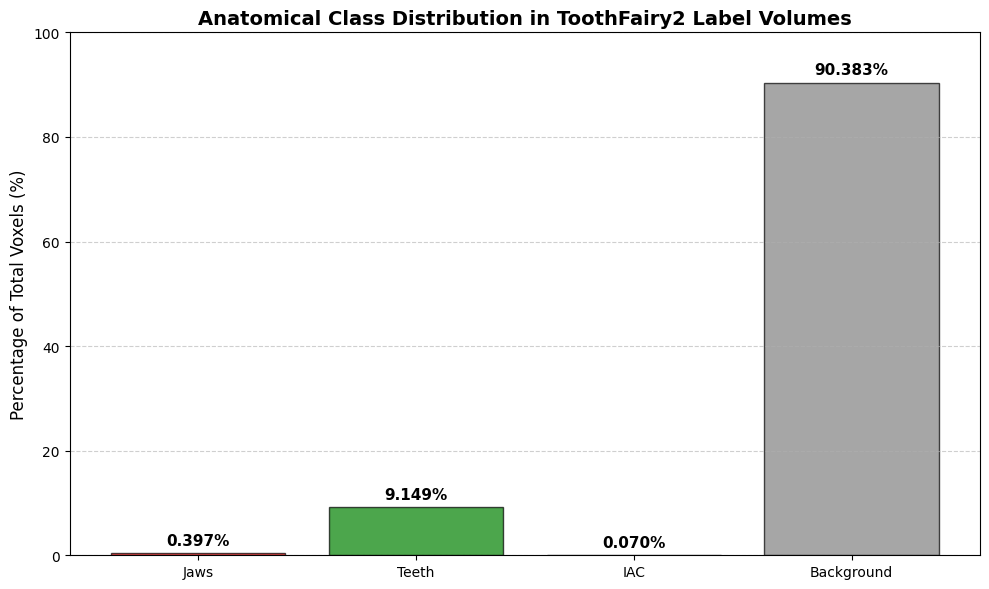


TOOTHFAIRY2 EXAMPLE-LEVEL TARGET DISTRIBUTION
Total Examples: 1,440
Teeth,Jaws,IAC      :     1165 (80.903%)
Teeth,IAC           :      131 ( 9.097%)
Teeth               :      106 ( 7.361%)
Teeth,Jaws          :       38 ( 2.639%)


In [ ]:
"""## Install Dependencies"""

import numpy as np
import cv2
import PIL.Image as Image
import sys

!pip install -q SimpleITK tqdm matplotlib

import SimpleITK as sitk
print(f"SimpleITK version: {sitk.Version_VersionString()}")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV (cv2) version: {cv2.__version__}")
print(f"PIL version: {getattr(Image, '__version__', 'Available')}")

"""## Define ToothFairy2 Volume Indexer"""

import os
import re
import glob

def index_toothfairy2_dataset(dataset_root):
    images_dir = os.path.join(dataset_root, 'imagesTr')
    labels_dir = os.path.join(dataset_root, 'labelsTr')

    id_pattern = re.compile(r'(ToothFairy2[FP]_\d+)')

    image_files = glob.glob(os.path.join(images_dir, '*.mha'))
    label_files = glob.glob(os.path.join(labels_dir, '*.mha'))

    image_index = {}
    for p in image_files:
        match = id_pattern.search(os.path.basename(p))
        if match:
            image_index[match.group(1)] = p

    label_index = {}
    for p in label_files:
        match = id_pattern.search(os.path.basename(p))
        if match:
            label_index[match.group(1)] = p

    matched_dataset = {}
    common_ids = set(image_index.keys()) & set(label_index.keys())

    for cid in sorted(common_ids):
        matched_dataset[cid] = {
            'image': image_index[cid],
            'label': label_index[cid],
        }

    print(f"[INFO] Scanned ToothFairy2 at: {dataset_root}")
    print(f"[INFO] Total image files found: {len(image_files)}")
    print(f"[INFO] Total label files found: {len(label_files)}")
    print(f"[INFO] Total matched pairs indexed: {len(matched_dataset)}")

    missing_labels = sorted(set(image_index.keys()) - set(label_index.keys()))
    missing_images = sorted(set(label_index.keys()) - set(image_index.keys()))

    if missing_labels:
        print(f"[WARN] {len(missing_labels)} images are missing labels. Example IDs: {missing_labels[:5]}")
    if missing_images:
        print(f"[WARN] {len(missing_images)} labels are missing images. Example IDs: {missing_images[:5]}")

    return matched_dataset

TF2_ROOT = '/content/drive/MyDrive/Dental_Project/ToothFairy2'
tf2_index = index_toothfairy2_dataset(TF2_ROOT)

if tf2_index:
    sample_id = list(tf2_index.keys())[0]
    print(f"\nSample Matched Pair ({sample_id}):")
    print(f"  Img: {os.path.basename(tf2_index[sample_id]['image'])}")
    print(f"  Lbl: {os.path.basename(tf2_index[sample_id]['label'])}")

"""## Implement Volume Preprocessing & Reference Resampling"""

import SimpleITK as sitk
import numpy as np

TARGET_SPACING = (0.3, 0.3, 0.3)

def load_and_canonicalize_mha(path):
    img = sitk.ReadImage(path)
    try:
        img = sitk.DICOMOrient(img, 'LPS')
    except Exception as e:
        print(f"[WARN] Orientation canonicalization failed for {path}: {e}")
    return img

def resample_to_spacing(img, target_spacing=TARGET_SPACING, is_label=False):
    original_spacing = img.GetSpacing()
    original_size = img.GetSize()

    out_size = [
        int(np.round(size * spacing / target))
        for size, spacing, target in zip(original_size, original_spacing, target_spacing)
    ]
    out_size = [max(1, v) for v in out_size]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(out_size)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(0)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor if is_label else sitk.sitkLinear)

    return resampler.Execute(img)

def resample_label_to_reference(label_img, reference_img):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference_img)
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(0)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)
    return resampler.Execute(label_img)

def load_case_arrays(image_path, label_path, target_spacing=TARGET_SPACING):
    image = load_and_canonicalize_mha(image_path)
    label = load_and_canonicalize_mha(label_path)

    image_rs = resample_to_spacing(image, target_spacing=target_spacing, is_label=False)
    label_rs = resample_label_to_reference(label, image_rs)

    vol_img = sitk.GetArrayFromImage(image_rs).astype(np.float32)
    vol_lbl = sitk.GetArrayFromImage(label_rs).astype(np.uint8)

    return vol_img, vol_lbl

print("Utility functions for ToothFairy2 volume preprocessing (LPS + reference-grid resampling) defined.")

"""## Develop Corrected Multichannel Montage Logic"""

import numpy as np
import cv2
from PIL import Image

def robust_normalize(vol, lower=1.0, upper=99.0):
    lo = np.percentile(vol, lower)
    hi = np.percentile(vol, upper)
    vol = np.clip(vol, lo, hi)
    return (vol - lo) / (hi - lo + 1e-6)

def create_multichannel_cbct(vol):
    low = robust_normalize(vol, 1.0, 95.0)
    base = robust_normalize(vol, 1.0, 99.0)
    high = robust_normalize(vol, 5.0, 99.5)
    return low, base, high

def resize_with_padding(img, target_size=(448, 448), interpolation=cv2.INTER_LINEAR):
    th, tw = target_size
    h, w = img.shape[:2]

    if h == 0 or w == 0:
        return np.zeros((th, tw), dtype=img.dtype)

    scale = min(tw / w, th / h)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))

    resized = cv2.resize(img, (nw, nh), interpolation=interpolation)
    canvas = np.zeros((th, tw), dtype=resized.dtype)

    y0 = (th - nh) // 2
    x0 = (tw - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas

def extract_view_projections(vol, z_idx, y_idx, x_idx, slab_frac=0.07):
    Z, Y, X = vol.shape

    z_idx = int(np.clip(z_idx, 0, Z - 1))
    y_idx = int(np.clip(y_idx, 0, Y - 1))
    x_idx = int(np.clip(x_idx, 0, X - 1))

    slab_z = max(1, int(round(Z * slab_frac)))
    slab_y = max(1, int(round(Y * slab_frac)))
    slab_x = max(1, int(round(X * slab_frac)))

    def get_projs(data, idx, slab, axis):
        start = max(0, idx - slab)
        end = min(data.shape[axis], idx + slab + 1)
        subset = np.take(data, np.arange(start, end), axis=axis)

        slice_img = np.take(data, idx, axis=axis)
        mip_img = np.max(subset, axis=axis)
        mean_img = np.mean(subset, axis=axis)

        return slice_img, mip_img, mean_img

    ax_s, ax_mip, ax_mean = get_projs(vol, z_idx, slab_z, 0)
    cor_s, cor_mip, cor_mean = get_projs(vol, y_idx, slab_y, 1)
    sag_s, sag_mip, sag_mean = get_projs(vol, x_idx, slab_x, 2)

    cor_s, cor_mip, cor_mean = [np.flipud(img) for img in [cor_s, cor_mip, cor_mean]]
    sag_s, sag_mip, sag_mean = [np.flipud(np.rot90(img, k=-1)) for img in [sag_s, sag_mip, sag_mean]]

    return {
        'axial': (ax_s, ax_mip, ax_mean),
        'coronal': (cor_s, cor_mip, cor_mean),
        'sagittal': (sag_s, sag_mip, sag_mean),
    }

def create_multispectral_montage(vol, z_idx, y_idx, x_idx, tile_size=(448, 448)):
    v_r, v_g, v_b = create_multichannel_cbct(vol)

    p_r = extract_view_projections(v_r, z_idx, y_idx, x_idx)
    p_g = extract_view_projections(v_g, z_idx, y_idx, x_idx)
    p_b = extract_view_projections(v_b, z_idx, y_idx, x_idx)

    def build_grid_channel(projs_dict):
        rows = []
        for orient in ['axial', 'coronal', 'sagittal']:
            imgs = [
                resize_with_padding(img, target_size=tile_size, interpolation=cv2.INTER_LINEAR)
                for img in projs_dict[orient]
            ]
            rows.append(np.hstack(imgs))
        return np.vstack(rows)

    r = build_grid_channel(p_r)
    g = build_grid_channel(p_g)
    b = build_grid_channel(p_b)

    rgb_montage = np.stack([
        (np.clip(r, 0.0, 1.0) * 255).astype(np.uint8),
        (np.clip(g, 0.0, 1.0) * 255).astype(np.uint8),
        (np.clip(b, 0.0, 1.0) * 255).astype(np.uint8),
    ], axis=-1)

    return Image.fromarray(rgb_montage)

print("Corrected multichannel montage logic for Axial/Coronal/Sagittal views implemented.")

"""## Create Anatomical Mask Projection (Optional Debug Only)"""

import numpy as np
from PIL import Image
import cv2

TEETH_LABELS = list(range(1, 33))
JAWS_LABELS = list(range(33, 41))
IAC_LABELS = [41, 42]

def create_anatomical_binary_volumes(label_vol):
    jaws_mask = np.isin(label_vol, JAWS_LABELS).astype(np.float32)
    teeth_mask = np.isin(label_vol, TEETH_LABELS).astype(np.float32)
    iac_mask = np.isin(label_vol, IAC_LABELS).astype(np.float32)
    return jaws_mask, teeth_mask, iac_mask

def create_mask_montage(label_vol, z_idx, y_idx, x_idx, tile_size=(448, 448)):
    v_jaws, v_teeth, v_iac = create_anatomical_binary_volumes(label_vol)

    p_jaws = extract_view_projections(v_jaws, z_idx, y_idx, x_idx)
    p_teeth = extract_view_projections(v_teeth, z_idx, y_idx, x_idx)
    p_iac = extract_view_projections(v_iac, z_idx, y_idx, x_idx)

    def build_grid_channel(projs_dict):
        rows = []
        for orient in ['axial', 'coronal', 'sagittal']:
            imgs = [
                resize_with_padding(img, target_size=tile_size, interpolation=cv2.INTER_NEAREST)
                for img in projs_dict[orient]
            ]
            rows.append(np.hstack(imgs))
        return np.vstack(rows)

    r_grid = build_grid_channel(p_jaws)
    g_grid = build_grid_channel(p_teeth)
    b_grid = build_grid_channel(p_iac)

    rgb_mask = np.stack([
        (np.clip(r_grid, 0, 1) * 255).astype(np.uint8),
        (np.clip(g_grid, 0, 1) * 255).astype(np.uint8),
        (np.clip(b_grid, 0, 1) * 255).astype(np.uint8),
    ], axis=-1)

    return Image.fromarray(rgb_mask)

print("Optional debug mask montage logic implemented.")

"""## Define Anatomy-Aware Sampling & Label Generation"""

import numpy as np

LABEL_ORDER = ["Teeth", "Jaws", "IAC"]

def get_anatomy_center(label_vol):
    coords = np.argwhere(label_vol > 0)
    if len(coords) == 0:
        Z, Y, X = label_vol.shape
        return Z // 2, Y // 2, X // 2

    zc = int(np.median(coords[:, 0]))
    yc = int(np.median(coords[:, 1]))
    xc = int(np.median(coords[:, 2]))
    return zc, yc, xc

def sample_z_positions(label_vol, num_positions=3):
    z_nonzero = np.where(np.any(label_vol > 0, axis=(1, 2)))[0]
    if len(z_nonzero) == 0:
        Z = label_vol.shape[0]
        return [Z // 2]

    z_min = int(z_nonzero[0])
    z_max = int(z_nonzero[-1])

    if num_positions == 1:
        return [(z_min + z_max) // 2]

    positions = [int(round(v)) for v in np.linspace(z_min, z_max, num_positions)]
    positions = [int(np.clip(v, 0, label_vol.shape[0] - 1)) for v in positions]
    return positions

def visible_classes_for_montage(label_vol, z_idx, y_idx, x_idx, slab_frac=0.07, min_pixels=300):
    v_jaws, v_teeth, v_iac = create_anatomical_binary_volumes(label_vol)
    Z, Y, X = label_vol.shape

    z_idx = int(np.clip(z_idx, 0, Z - 1))
    y_idx = int(np.clip(y_idx, 0, Y - 1))
    x_idx = int(np.clip(x_idx, 0, X - 1))

    slab_z = max(1, int(round(Z * slab_frac)))
    slab_y = max(1, int(round(Y * slab_frac)))
    slab_x = max(1, int(round(X * slab_frac)))

    def slab_sum(vol, idx, slab, axis):
        start = max(0, idx - slab)
        end = min(vol.shape[axis], idx + slab + 1)
        subset = np.take(vol, np.arange(start, end), axis=axis)
        return float(subset.sum())

    scores = {
        "Teeth": (
            slab_sum(v_teeth, z_idx, slab_z, 0) +
            slab_sum(v_teeth, y_idx, slab_y, 1) +
            slab_sum(v_teeth, x_idx, slab_x, 2)
        ),
        "Jaws": (
            slab_sum(v_jaws, z_idx, slab_z, 0) +
            slab_sum(v_jaws, y_idx, slab_y, 1) +
            slab_sum(v_jaws, x_idx, slab_x, 2)
        ),
        "IAC": (
            slab_sum(v_iac, z_idx, slab_z, 0) +
            slab_sum(v_iac, y_idx, slab_y, 1) +
            slab_sum(v_iac, x_idx, slab_x, 2)
        ),
    }

    visible = [label for label in LABEL_ORDER if scores[label] >= min_pixels]
    return visible

print("Anatomy-aware target generation logic implemented.")

"""## Generate Corrected Multi-View Dataset & JSONL"""

import os
import json
import numpy as np
from tqdm import tqdm

OUT_DIR = '/content/ToothFairy_Preprocessed'
IMG_DIR = os.path.join(OUT_DIR, 'images')
DBG_MASK_DIR = os.path.join(OUT_DIR, 'debug_masks')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(DBG_MASK_DIR, exist_ok=True)

JSONL_OUT = os.path.join(OUT_DIR, 'dataset_qwen25vl_tf2_corrected.jsonl')
MISSING_LOG = os.path.join(OUT_DIR, 'missing_tf2_corrected.txt')

SAVE_DEBUG_MASKS = True
NUM_Z_POSITIONS = 3
MIN_PIXELS = 300
SLAB_FRAC = 0.07
TILE_SIZE = (448, 448)

n_processed = 0
n_failed = 0
n_examples = 0
failed_ids = []

with open(JSONL_OUT, 'w', encoding='utf-8') as f_jsonl:
    for tid, paths in tqdm(tf2_index.items(), desc='Processing TF2 Corrected'):
        try:
            vol_img, vol_lbl = load_case_arrays(
                paths['image'],
                paths['label'],
                target_spacing=TARGET_SPACING,
            )

            if min(vol_img.shape) < 16 or vol_img.shape != vol_lbl.shape:
                raise ValueError(f"Invalid volume shapes for {tid}: image={vol_img.shape}, label={vol_lbl.shape}")

            z_center, y_center, x_center = get_anatomy_center(vol_lbl)
            z_positions = sample_z_positions(vol_lbl, num_positions=NUM_Z_POSITIONS)

            case_examples = 0

            for i, z in enumerate(z_positions):
                cbct_montage = create_multispectral_montage(
                    vol_img,
                    z_idx=z,
                    y_idx=y_center,
                    x_idx=x_center,
                    tile_size=TILE_SIZE,
                )

                target_classes = visible_classes_for_montage(
                    vol_lbl,
                    z_idx=z,
                    y_idx=y_center,
                    x_idx=x_center,
                    slab_frac=SLAB_FRAC,
                    min_pixels=MIN_PIXELS,
                )

                target_classes = [x for x in LABEL_ORDER if x in target_classes]

                if not target_classes:
                    continue

                img_name = f'{tid}_z{i}.png'
                img_path = os.path.join(IMG_DIR, img_name)
                cbct_montage.save(img_path)

                mask_path = os.path.join(DBG_MASK_DIR, f'{tid}_z{i}_mask.png')

                if SAVE_DEBUG_MASKS:
                    dbg_mask = create_mask_montage(
                        vol_lbl,
                        z_idx=z,
                        y_idx=y_center,
                        x_idx=x_center,
                        tile_size=TILE_SIZE,
                    )
                    dbg_mask.save(mask_path)
                else:
                    mask_path = None
                record = {
                    'id': f'{tid}_z{i}',
                    'messages': [
                        {
                            'role': 'user',
                            'content': [
                                {'type': 'image', 'image': img_path},
                                {
                                    'type': 'text',
                                    'text': 'Identify which anatomical structures are visible in this CBCT montage. Return only a JSON array chosen from ["Teeth", "Jaws", "IAC"].'
                                }
                            ]
                        },
                        {
                            'role': 'assistant',
                            'content': [
                                {'type': 'text', 'text': json.dumps(target_classes, separators=(',', ':'))}
                            ]
                        }
                    ],
                    'meta': {
                        'patient_id': tid,
                        'z_slice': int(z),
                        'y_center': int(y_center),
                        'x_center': int(x_center),
                        'label_space': LABEL_ORDER,
                        'source': 'ToothFairy2',
                        'target_spacing': list(TARGET_SPACING),
                        'slab_frac': float(SLAB_FRAC),
                        'min_pixels': int(MIN_PIXELS),
                        'mask_path': mask_path,
                    }
                }

                f_jsonl.write(json.dumps(record) + '\n')
                case_examples += 1
                n_examples += 1

            if case_examples > 0:
                n_processed += 1
            else:
                failed_ids.append(tid)
                n_failed += 1

        except Exception as e:
            print(f'\n[ERROR] Failed to process {tid}: {e}')
            failed_ids.append(tid)
            n_failed += 1

with open(MISSING_LOG, 'w', encoding='utf-8') as f_miss:
    for fid in failed_ids:
        f_miss.write(fid + '\n')

print(f'\n[DONE] Successfully processed cases: {n_processed}')
print(f'[DONE] Failed/Skipped cases: {n_failed}')
print(f'[DONE] Total JSONL examples written: {n_examples}')
print(f'[DONE] JSONL saved to: {JSONL_OUT}')

"""## Move Output to Google Drive"""

import os
import shutil

source_dir = OUT_DIR
dest_parent = '/content/drive/MyDrive/Dental_Project'
dest_dir = os.path.join(dest_parent, os.path.basename(OUT_DIR))

if os.path.exists(source_dir):
    os.makedirs(dest_parent, exist_ok=True)

    if os.path.exists(dest_dir):
        print(f'Warning: {dest_dir} already exists. Removing old version...')
        shutil.rmtree(dest_dir)

    shutil.move(source_dir, dest_parent)
    print(f'Successfully moved {source_dir} to {dest_dir}')
else:
    print(f'Error: Source directory {source_dir} not found.')

"""## Verify Saved Outputs"""

import os

drive_path = os.path.join('/content/drive/MyDrive/Dental_Project', os.path.basename(OUT_DIR))
img_dir = os.path.join(drive_path, 'images')
jsonl_file = os.path.join(drive_path, 'dataset_qwen25vl_tf2_corrected.jsonl')

if os.path.exists(drive_path):
    print(f'Checking folder: {drive_path}')

    if os.path.exists(jsonl_file):
        with open(jsonl_file, 'r', encoding='utf-8') as f:
            line_count = sum(1 for _ in f)
        print(f'[OK] Found JSONL: {os.path.basename(jsonl_file)} ({line_count} records)')
    else:
        print('[ERROR] JSONL file missing!')

    if os.path.exists(img_dir):
        files = os.listdir(img_dir)
        print(f'[OK] Found images folder: {len(files)} files total')

        if len(files) > 0:
            print('\nSample files in drive:')
            for f in sorted(files)[:5]:
                print(f' - {f}')
    else:
        print('[ERROR] Images folder missing!')
else:
    print(f'[ERROR] Could not find the folder at {drive_path}')

"""## Analyze Voxel-Level Class Distribution"""

import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_label_distribution(tf2_index):
    counts = {'Jaws': 0, 'Teeth': 0, 'IAC': 0, 'Background': 0}
    total_voxels = 0

    for tid, paths in tqdm(tf2_index.items(), desc='Analyzing Label Volumes'):
        try:
            _, vol_lbl = load_case_arrays(
                paths['image'],
                paths['label'],
                target_spacing=TARGET_SPACING,
            )

            teeth_count = int(np.isin(vol_lbl, TEETH_LABELS).sum())
            jaws_count = int(np.isin(vol_lbl, JAWS_LABELS).sum())
            iac_count = int(np.isin(vol_lbl, IAC_LABELS).sum())

            total_case_voxels = int(vol_lbl.size)
            background_count = total_case_voxels - (teeth_count + jaws_count + iac_count)

            counts['Teeth'] += teeth_count
            counts['Jaws'] += jaws_count
            counts['IAC'] += iac_count
            counts['Background'] += background_count
            total_voxels += total_case_voxels

        except Exception as e:
            print(f"[WARN] Failed label analysis for {tid}: {e}")

    percentages = {
        k: (v / total_voxels) * 100 if total_voxels > 0 else 0.0
        for k, v in counts.items()
    }

    return counts, percentages, total_voxels

counts, percentages, total_voxels = analyze_label_distribution(tf2_index)

print("\n" + "=" * 40)
print("TOOTHFAIRY2 VOXEL-LEVEL DISTRIBUTION")
print("=" * 40)
print(f"Total Voxels Analyzed: {total_voxels:,}")
for label in ['Jaws', 'Teeth', 'IAC', 'Background']:
    print(f"{label:12s}: {counts[label]:15,d} voxels ({percentages[label]:6.3f}%)")
print("=" * 40)

classes = ['Jaws', 'Teeth', 'IAC', 'Background']
percentages_plot = [
    percentages['Jaws'],
    percentages['Teeth'],
    percentages['IAC'],
    percentages['Background'],
]
colors = ['red', 'green', 'blue', 'gray']

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, percentages_plot, color=colors, edgecolor='black', alpha=0.7)

plt.title('Anatomical Class Distribution in ToothFairy2 Label Volumes', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Voxels (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.3f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

"""## Analyze Example-Level Target Distribution"""

from collections import Counter

def analyze_example_target_distribution(jsonl_path):
    target_counter = Counter()
    total_records = 0

    if not os.path.exists(jsonl_path):
        print(f"[ERROR] JSONL not found: {jsonl_path}")
        return target_counter, total_records

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            row = json.loads(line)
            assistant_text = row['messages'][1]['content'][0]['text']
            labels = json.loads(assistant_text)
            key = ','.join(labels) if labels else 'None'
            target_counter[key] += 1
            total_records += 1

    return target_counter, total_records

target_counter, total_records = analyze_example_target_distribution(jsonl_file)

print("\n" + "=" * 40)
print("TOOTHFAIRY2 EXAMPLE-LEVEL TARGET DISTRIBUTION")
print("=" * 40)
print(f"Total Examples: {total_records:,}")
for key, value in sorted(target_counter.items(), key=lambda x: (-x[1], x[0])):
    pct = (value / total_records) * 100 if total_records > 0 else 0.0
    print(f"{key:20s}: {value:8d} ({pct:6.3f}%)")
print("=" * 40)

# **MMDENTAL PRE-MODELLING PIPELINE**

In [ ]:
import collections
import json
import math
import os
import random
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd


# ============================================================
# 0) PATHS
# ============================================================

MMD_ROOT = "/content/drive/MyDrive/Dental_Project/MMDental_Preprocessed"

SOURCE_JSONL = os.path.join(MMD_ROOT, "dataset_qwen25vl.jsonl")
SOURCE_STATS_JSON = os.path.join(MMD_ROOT, "dataset_stats.json")
SOURCE_FILTERED_CSV = os.path.join(MMD_ROOT, "cleaned_medical_records_filtered.csv")

OUT_ROOT = os.path.join(MMD_ROOT, "pre_modeling_v2")
os.makedirs(OUT_ROOT, exist_ok=True)

MULTILABEL_DIR = os.path.join(OUT_ROOT, "multilabel_4way")
SINGLE4_DIR = os.path.join(OUT_ROOT, "single_label_4class")
CLASS3_DIR = os.path.join(OUT_ROOT, "single_label_3class")
BINARY_DIR = os.path.join(OUT_ROOT, "binary")

for d in [MULTILABEL_DIR, SINGLE4_DIR, CLASS3_DIR, BINARY_DIR]:
    os.makedirs(d, exist_ok=True)

AUDIT_CSV = os.path.join(OUT_ROOT, "manual_audit_candidates.csv")
SPLIT_REPORT_JSON = os.path.join(OUT_ROOT, "split_report.json")
LEAKAGE_REPORT_JSON = os.path.join(OUT_ROOT, "leakage_report.json")
TRAINING_PLAN_JSON = os.path.join(OUT_ROOT, "training_plan.json")


# ============================================================
# 1) CONFIG
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

LABEL_SPACE_4 = ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT"]
LABEL_SPACE_3 = ["ENDO", "PERIO", "OTHER"]
LABEL_SPACE_BINARY = ["NORMAL", "ABNORMAL"]

SINGLE_LABEL_PRIORITY = ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT"]

AUDIT_SAMPLES_PER_CLASS = 25


# ============================================================
# 2) IO HELPERS
# ============================================================

def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, tuple):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if pd.isna(obj):
        return None

    return obj


def load_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                rows.append(json.loads(s))
    return rows


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(to_jsonable(row), ensure_ascii=False) + "\n")


def write_json(path: str, obj: Dict[str, Any]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2, ensure_ascii=False)


# ============================================================
# 3) BASIC HELPERS
# ============================================================

def safe_str(x: Any) -> str:
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    s = str(x).strip()
    if s.lower() == "nan":
        return ""
    return s


def get_patient_id(rec: Dict[str, Any]) -> str:
    meta = rec.get("meta", {})
    pid = safe_str(meta.get("patient_id", rec.get("id", "")))
    if not pid:
        raise ValueError("Missing patient_id")
    return pid


def get_labels(rec: Dict[str, Any]) -> List[str]:
    labels = rec.get("labels", None)
    if isinstance(labels, list):
        return [safe_str(x) for x in labels if safe_str(x)]

    meta = rec.get("meta", {})
    labels2 = meta.get("labels", None)
    if isinstance(labels2, list):
        return [safe_str(x) for x in labels2 if safe_str(x)]

    return []


def get_first_user_message(rec: Dict[str, Any]) -> Dict[str, Any]:
    for msg in rec.get("messages", []):
        if msg.get("role") == "user":
            return msg
    raise ValueError(f"Missing user message for id={rec.get('id')}")


def get_first_image_path(rec: Dict[str, Any]) -> str:
    user = get_first_user_message(rec)
    content = user.get("content", [])
    for block in content:
        if isinstance(block, dict) and block.get("type") == "image":
            return safe_str(block.get("image", ""))
    return ""


def get_num_images(rec: Dict[str, Any]) -> int:
    user = get_first_user_message(rec)
    content = user.get("content", [])
    return sum(1 for block in content if isinstance(block, dict) and block.get("type") == "image")


# ============================================================
# 4) TASK DERIVATIONS
# ============================================================

def to_single_label(labels: List[str]) -> str:
    if not labels:
        return "NORMAL"
    for lbl in SINGLE_LABEL_PRIORITY:
        if lbl in labels:
            return lbl
    return labels[0]


def to_3class_label(labels: List[str]) -> str:
    if "ENDO" in labels:
        return "ENDO"
    if "PERIO" in labels:
        return "PERIO"
    return "OTHER"


def to_binary_label(labels: List[str]) -> str:
    return "ABNORMAL" if len(labels) > 0 else "NORMAL"


# ============================================================
# 5) GROUPING
# ============================================================

def group_by_patient(records: List[Dict[str, Any]]) -> Dict[str, List[Dict[str, Any]]]:
    grouped = collections.defaultdict(list)
    for rec in records:
        grouped[get_patient_id(rec)].append(rec)
    return dict(grouped)


def patient_union_labels(group: List[Dict[str, Any]]) -> List[str]:
    labels = set()
    for rec in group:
        labels.update(get_labels(rec))
    return sorted(labels)


def patient_single_label(group: List[Dict[str, Any]]) -> str:
    return to_single_label(patient_union_labels(group))


def patient_3class(group: List[Dict[str, Any]]) -> str:
    return to_3class_label(patient_union_labels(group))


def patient_binary(group: List[Dict[str, Any]]) -> str:
    return to_binary_label(patient_union_labels(group))


# ============================================================
# 6) SPLITTING
# ============================================================

def stratified_patient_split(
    patient_groups: Dict[str, List[Dict[str, Any]]],
    seed: int = SEED,
    train_ratio: float = TRAIN_RATIO,
    val_ratio: float = VAL_RATIO,
    test_ratio: float = TEST_RATIO,
) -> Tuple[List[str], List[str], List[str]]:
    rng = random.Random(seed)

    label_buckets = collections.defaultdict(list)
    for pid, group in patient_groups.items():
        lbl = patient_single_label(group)
        label_buckets[lbl].append(pid)

    train_ids = []
    val_ids = []
    test_ids = []

    for lbl in sorted(label_buckets.keys()):
        pids = list(label_buckets[lbl])
        rng.shuffle(pids)

        n = len(pids)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_test = n - n_train - n_val

        train_ids.extend(pids[:n_train])
        val_ids.extend(pids[n_train:n_train + n_val])
        test_ids.extend(pids[n_train + n_val:])

    rng.shuffle(train_ids)
    rng.shuffle(val_ids)
    rng.shuffle(test_ids)

    return train_ids, val_ids, test_ids


def flatten_patient_groups(patient_groups: Dict[str, List[Dict[str, Any]]], patient_ids: List[str]) -> List[Dict[str, Any]]:
    rows = []
    for pid in patient_ids:
        rows.extend(patient_groups[pid])
    return rows


def check_leakage(train_ids: List[str], val_ids: List[str], test_ids: List[str]) -> Dict[str, Any]:
    train_set = set(train_ids)
    val_set = set(val_ids)
    test_set = set(test_ids)

    overlap_train_val = sorted(train_set & val_set)
    overlap_train_test = sorted(train_set & test_set)
    overlap_val_test = sorted(val_set & test_set)

    return {
        "n_train_patients": len(train_set),
        "n_val_patients": len(val_set),
        "n_test_patients": len(test_set),
        "train_val_overlap_count": len(overlap_train_val),
        "train_test_overlap_count": len(overlap_train_test),
        "val_test_overlap_count": len(overlap_val_test),
        "train_val_overlap_examples": overlap_train_val[:20],
        "train_test_overlap_examples": overlap_train_test[:20],
        "val_test_overlap_examples": overlap_val_test[:20],
        "is_clean": len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0,
    }


# ============================================================
# 7) RECORD REWRITERS
# ============================================================

def deep_copy_record(rec: Dict[str, Any]) -> Dict[str, Any]:
    return json.loads(json.dumps(rec))


def rewrite_for_single_label_4class(rec: Dict[str, Any]) -> Dict[str, Any]:
    new_rec = deep_copy_record(rec)
    label = to_single_label(get_labels(rec))

    new_rec["meta"]["task_variant"] = "single_label_4class"
    new_rec["meta"]["single_label"] = label

    new_rec["messages"][0]["content"][-1]["text"] = (
        "Classify the dental pathology in these CBCT montage images.\n"
        "Return exactly one label from: ENDO, PERIO, DEV_POS, CARIES_STRUCT, NORMAL.\n"
        "Return only plain text in the format: LABEL: <label>"
    )
    new_rec["messages"][1]["content"][0]["text"] = f"LABEL: {label}"
    return new_rec


def rewrite_for_3class(rec: Dict[str, Any]) -> Dict[str, Any]:
    new_rec = deep_copy_record(rec)
    label = to_3class_label(get_labels(rec))

    new_rec["meta"]["task_variant"] = "single_label_3class"
    new_rec["meta"]["class_3"] = label

    new_rec["messages"][0]["content"][-1]["text"] = (
        "Classify the dental pathology in these CBCT montage images.\n"
        "Return exactly one label from: ENDO, PERIO, OTHER.\n"
        "Return only plain text in the format: LABEL: <label>"
    )
    new_rec["messages"][1]["content"][0]["text"] = f"LABEL: {label}"
    return new_rec


def rewrite_for_binary(rec: Dict[str, Any]) -> Dict[str, Any]:
    new_rec = deep_copy_record(rec)
    label = to_binary_label(get_labels(rec))

    new_rec["meta"]["task_variant"] = "binary"
    new_rec["meta"]["binary_label"] = label

    new_rec["messages"][0]["content"][-1]["text"] = (
        "Determine whether these CBCT montage images show abnormal dental pathology.\n"
        "Return exactly one label from: NORMAL, ABNORMAL.\n"
        "Return only plain text in the format: LABEL: <label>"
    )
    new_rec["messages"][1]["content"][0]["text"] = f"LABEL: {label}"
    return new_rec


# ============================================================
# 8) REPORTING
# ============================================================

def summarize_split(records: List[Dict[str, Any]], split_name: str) -> Dict[str, Any]:
    patient_groups = group_by_patient(records)

    multilabel_counter = collections.Counter()
    single_counter = collections.Counter()
    class3_counter = collections.Counter()
    binary_counter = collections.Counter()

    for pid, group in patient_groups.items():
        union_labels = patient_union_labels(group)
        multilabel_key = ",".join(union_labels) if union_labels else "NORMAL"
        multilabel_counter[multilabel_key] += 1
        single_counter[patient_single_label(group)] += 1
        class3_counter[patient_3class(group)] += 1
        binary_counter[patient_binary(group)] += 1

    return {
        "split_name": split_name,
        "num_records": len(records),
        "num_patients": len(patient_groups),
        "multilabel_distribution": dict(multilabel_counter),
        "single_label_distribution": dict(single_counter),
        "class3_distribution": dict(class3_counter),
        "binary_distribution": dict(binary_counter),
    }


# ============================================================
# 9) TRAIN-ONLY IMBALANCE HANDLING STATS
# ============================================================

def compute_class_weights_from_counts(label_counts: Dict[str, int]) -> Dict[str, float]:
    total = float(sum(label_counts.values()))
    n_classes = float(len(label_counts))

    raw = {}
    for cls, count in label_counts.items():
        raw[cls] = total / (n_classes * max(1.0, float(count)))

    mean_w = float(np.mean(list(raw.values())))
    normalized = {cls: (w / mean_w) for cls, w in raw.items()}
    return normalized


def compute_train_single_label_counts(train_records: List[Dict[str, Any]]) -> Dict[str, int]:
    patient_groups = group_by_patient(train_records)
    counts = collections.Counter()
    for _, group in patient_groups.items():
        counts[patient_single_label(group)] += 1
    return {cls: int(counts.get(cls, 0)) for cls in ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT", "NORMAL"]}


def compute_train_3class_counts(train_records: List[Dict[str, Any]]) -> Dict[str, int]:
    patient_groups = group_by_patient(train_records)
    counts = collections.Counter()
    for _, group in patient_groups.items():
        counts[patient_3class(group)] += 1
    return {cls: int(counts.get(cls, 0)) for cls in LABEL_SPACE_3}


def compute_train_binary_counts(train_records: List[Dict[str, Any]]) -> Dict[str, int]:
    patient_groups = group_by_patient(train_records)
    counts = collections.Counter()
    for _, group in patient_groups.items():
        counts[patient_binary(group)] += 1
    return {cls: int(counts.get(cls, 0)) for cls in LABEL_SPACE_BINARY}


def compute_weighted_sampler_weights(records: List[Dict[str, Any]], mode: str) -> List[float]:
    patient_groups = group_by_patient(records)

    if mode == "single_label_4class":
        patient_class = {pid: patient_single_label(group) for pid, group in patient_groups.items()}
        class_counts = collections.Counter(patient_class.values())
    elif mode == "single_label_3class":
        patient_class = {pid: patient_3class(group) for pid, group in patient_groups.items()}
        class_counts = collections.Counter(patient_class.values())
    elif mode == "binary":
        patient_class = {pid: patient_binary(group) for pid, group in patient_groups.items()}
        class_counts = collections.Counter(patient_class.values())
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    weights = []
    for rec in records:
        pid = get_patient_id(rec)
        cls = patient_class[pid]
        weights.append(1.0 / max(1, class_counts[cls]))

    return weights


# ============================================================
# 10) AUDIT CSV
# ============================================================

def build_audit_csv(records: List[Dict[str, Any]], out_csv: str, per_class: int = AUDIT_SAMPLES_PER_CLASS, seed: int = SEED) -> None:
    rng = random.Random(seed)
    by_class = collections.defaultdict(list)

    for rec in records:
        cls = to_single_label(get_labels(rec))
        by_class[cls].append(rec)

    rows = []
    for cls in sorted(by_class.keys()):
        recs = list(by_class[cls])
        rng.shuffle(recs)
        sample = recs[:per_class]

        for rec in sample:
            meta = rec.get("meta", {})
            rows.append({
                "patient_id": get_patient_id(rec),
                "single_label": to_single_label(get_labels(rec)),
                "multi_labels": ",".join(get_labels(rec)) if get_labels(rec) else "NORMAL",
                "age": safe_str(meta.get("age", "")),
                "sex": safe_str(meta.get("sex", "")),
                "main_appeal": safe_str(meta.get("main_appeal", "")),
                "fdi_teeth": ",".join(meta.get("fdi_teeth", [])) if isinstance(meta.get("fdi_teeth", []), list) else safe_str(meta.get("fdi_teeth", "")),
                "num_images": get_num_images(rec),
                "first_image_path": get_first_image_path(rec),
                "audit_label_correct": "",
                "audit_image_quality": "",
                "audit_pathology_visible": "",
                "audit_notes": "",
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print(f"[OK] Wrote audit CSV: {out_csv} ({len(df)} rows)")


# ============================================================
# 11) SAVE SPLITS
# ============================================================

def save_split_family(base_dir: str, train_rows: List[Dict[str, Any]], val_rows: List[Dict[str, Any]], test_rows: List[Dict[str, Any]]) -> Dict[str, str]:
    train_path = os.path.join(base_dir, "train.jsonl")
    val_path = os.path.join(base_dir, "val.jsonl")
    test_path = os.path.join(base_dir, "test.jsonl")

    write_jsonl(train_path, train_rows)
    write_jsonl(val_path, val_rows)
    write_jsonl(test_path, test_rows)

    return {
        "train": train_path,
        "val": val_path,
        "test": test_path,
    }


# ============================================================
# 12) MAIN
# ============================================================

def main():
    print("[LOAD] Reading source JSONL...")
    records = load_jsonl(SOURCE_JSONL)
    print(f"[INFO] Loaded records: {len(records)}")

    patient_groups = group_by_patient(records)
    print(f"[INFO] Unique patients: {len(patient_groups)}")

    print("[SPLIT] Building patient-level stratified splits...")
    train_ids, val_ids, test_ids = stratified_patient_split(
        patient_groups=patient_groups,
        seed=SEED,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
    )

    leakage = check_leakage(train_ids, val_ids, test_ids)
    write_json(LEAKAGE_REPORT_JSON, leakage)
    print(f"[LEAKAGE] Clean split: {leakage['is_clean']}")

    train_records = flatten_patient_groups(patient_groups, train_ids)
    val_records = flatten_patient_groups(patient_groups, val_ids)
    test_records = flatten_patient_groups(patient_groups, test_ids)

    print(f"[SPLIT] train records={len(train_records)} | patients={len(train_ids)}")
    print(f"[SPLIT] val records={len(val_records)} | patients={len(val_ids)}")
    print(f"[SPLIT] test records={len(test_records)} | patients={len(test_ids)}")

    # Save original multilabel split
    multilabel_paths = save_split_family(
        MULTILABEL_DIR,
        train_records,
        val_records,
        test_records,
    )

    # Save single-label 4-class split
    train_single4 = [rewrite_for_single_label_4class(r) for r in train_records]
    val_single4 = [rewrite_for_single_label_4class(r) for r in val_records]
    test_single4 = [rewrite_for_single_label_4class(r) for r in test_records]
    single4_paths = save_split_family(SINGLE4_DIR, train_single4, val_single4, test_single4)

    # Save 3-class split
    train_3 = [rewrite_for_3class(r) for r in train_records]
    val_3 = [rewrite_for_3class(r) for r in val_records]
    test_3 = [rewrite_for_3class(r) for r in test_records]
    class3_paths = save_split_family(CLASS3_DIR, train_3, val_3, test_3)

    # Save binary split
    train_bin = [rewrite_for_binary(r) for r in train_records]
    val_bin = [rewrite_for_binary(r) for r in val_records]
    test_bin = [rewrite_for_binary(r) for r in test_records]
    binary_paths = save_split_family(BINARY_DIR, train_bin, val_bin, test_bin)

    # Train-only imbalance stats
    train_single_counts = compute_train_single_label_counts(train_records)
    train_single_weights = compute_class_weights_from_counts(train_single_counts)

    train_3_counts = compute_train_3class_counts(train_records)
    train_3_weights = compute_class_weights_from_counts(train_3_counts)

    train_binary_counts = compute_train_binary_counts(train_records)
    train_binary_weights = compute_class_weights_from_counts(train_binary_counts)

    # Weighted sampler weights
    sampler_single4 = compute_weighted_sampler_weights(train_records, mode="single_label_4class")
    sampler_3class = compute_weighted_sampler_weights(train_records, mode="single_label_3class")
    sampler_binary = compute_weighted_sampler_weights(train_records, mode="binary")

    # Save sampler weights as plain JSON lists
    write_json(os.path.join(SINGLE4_DIR, "train_sampler_weights.json"), {"weights": sampler_single4})
    write_json(os.path.join(CLASS3_DIR, "train_sampler_weights.json"), {"weights": sampler_3class})
    write_json(os.path.join(BINARY_DIR, "train_sampler_weights.json"), {"weights": sampler_binary})

    # Build audit CSV from full source set
    build_audit_csv(records, AUDIT_CSV, per_class=AUDIT_SAMPLES_PER_CLASS, seed=SEED)

    split_report = {
        "source_jsonl": SOURCE_JSONL,
        "num_source_records": len(records),
        "num_source_patients": len(patient_groups),
        "leakage": leakage,
        "multilabel_summary": {
            "train": summarize_split(train_records, "train"),
            "val": summarize_split(val_records, "val"),
            "test": summarize_split(test_records, "test"),
        },
        "paths": {
            "multilabel_4way": multilabel_paths,
            "single_label_4class": single4_paths,
            "single_label_3class": class3_paths,
            "binary": binary_paths,
            "audit_csv": AUDIT_CSV,
            "leakage_report_json": LEAKAGE_REPORT_JSON,
        },
    }

    write_json(SPLIT_REPORT_JSON, split_report)

    training_plan = {
        "recommended_primary_metric": "macro_f1",
        "recommended_secondary_metric": "balanced_accuracy",
        "recommended_training_order": [
            "binary",
            "single_label_3class",
            "single_label_4class",
        ],
        "imbalance_handling_policy": {
            "split_first": True,
            "apply_augmentation_only_to_train": True,
            "recommended": "online_class_aware_augmentation_plus_mild_class_weights",
            "avoid": [
                "pre_split_augmentation",
                "undersampling_majority_classes",
                "heavy_offline_duplication_to_exact_target_count"
            ],
        },
        "train_only_statistics": {
            "single_label_4class_counts": train_single_counts,
            "single_label_4class_class_weights": train_single_weights,
            "single_label_3class_counts": train_3_counts,
            "single_label_3class_class_weights": train_3_weights,
            "binary_counts": train_binary_counts,
            "binary_class_weights": train_binary_weights,
        },
        "notes": [
            "Use augmentation only in the training dataloader.",
            "Use either WeightedRandomSampler or class-weighted loss, and keep class weights mild.",
            "Do not rebalance validation or test splits.",
            "Use patient-level splits only.",
        ],
    }

    write_json(TRAINING_PLAN_JSON, training_plan)

    print("\n[DONE] MMDental pre-modelling completed.")
    print(f"[DONE] Split report: {SPLIT_REPORT_JSON}")
    print(f"[DONE] Leakage report: {LEAKAGE_REPORT_JSON}")
    print(f"[DONE] Training plan: {TRAINING_PLAN_JSON}")
    print(f"[DONE] Audit CSV: {AUDIT_CSV}")
    print(f"[DONE] Multilabel split dir: {MULTILABEL_DIR}")
    print(f"[DONE] Single-label 4-class split dir: {SINGLE4_DIR}")
    print(f"[DONE] 3-class split dir: {CLASS3_DIR}")
    print(f"[DONE] Binary split dir: {BINARY_DIR}")


if __name__ == "__main__":
    main()

[LOAD] Reading source JSONL...
[INFO] Loaded records: 403
[INFO] Unique patients: 403
[SPLIT] Building patient-level stratified splits...
[LEAKAGE] Clean split: True
[SPLIT] train records=281 | patients=281
[SPLIT] val records=60 | patients=60
[SPLIT] test records=62 | patients=62
[OK] Wrote audit CSV: /content/drive/MyDrive/Dental_Project/MMDental_Preprocessed/pre_modeling_v2/manual_audit_candidates.csv (125 rows)

[DONE] MMDental pre-modelling completed.
[DONE] Split report: /content/drive/MyDrive/Dental_Project/MMDental_Preprocessed/pre_modeling_v2/split_report.json
[DONE] Leakage report: /content/drive/MyDrive/Dental_Project/MMDental_Preprocessed/pre_modeling_v2/leakage_report.json
[DONE] Training plan: /content/drive/MyDrive/Dental_Project/MMDental_Preprocessed/pre_modeling_v2/training_plan.json
[DONE] Audit CSV: /content/drive/MyDrive/Dental_Project/MMDental_Preprocessed/pre_modeling_v2/manual_audit_candidates.csv
[DONE] Multilabel split dir: /content/drive/MyDrive/Dental_Project

# **TOOTHFAIRY2 PRE-MODELLING PIPELINE**

In [ ]:
import collections
import json
import os
import random
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd


# ============================================================
# 0) PATHS
# ============================================================

TF2_ROOT = "/content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed"

SOURCE_JSONL = os.path.join(TF2_ROOT, "dataset_qwen25vl_tf2_corrected.jsonl")

OUT_ROOT = os.path.join(TF2_ROOT, "pre_modeling_v1")
os.makedirs(OUT_ROOT, exist_ok=True)

SPLIT_DIR = os.path.join(OUT_ROOT, "stage1_alignment")
os.makedirs(SPLIT_DIR, exist_ok=True)

TRAIN_JSONL = os.path.join(SPLIT_DIR, "train.jsonl")
VAL_JSONL = os.path.join(SPLIT_DIR, "val.jsonl")
TEST_JSONL = os.path.join(SPLIT_DIR, "test.jsonl")

AUDIT_CSV = os.path.join(OUT_ROOT, "manual_audit_candidates.csv")
SPLIT_REPORT_JSON = os.path.join(OUT_ROOT, "split_report.json")
LEAKAGE_REPORT_JSON = os.path.join(OUT_ROOT, "leakage_report.json")
TRAINING_PLAN_JSON = os.path.join(OUT_ROOT, "training_plan.json")


# ============================================================
# 1) CONFIG
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

LABEL_ORDER = ["Teeth", "Jaws", "IAC"]

AUDIT_SAMPLES_PER_TARGET = 25


# ============================================================
# 2) IO HELPERS
# ============================================================

def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, tuple):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if pd.isna(obj):
        return None

    return obj


def load_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                rows.append(json.loads(s))
    return rows


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(to_jsonable(row), ensure_ascii=False) + "\n")


def write_json(path: str, obj: Dict[str, Any]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2, ensure_ascii=False)


# ============================================================
# 3) BASIC HELPERS
# ============================================================

def safe_str(x: Any) -> str:
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    s = str(x).strip()
    if s.lower() == "nan":
        return ""
    return s


def get_patient_id(rec: Dict[str, Any]) -> str:
    meta = rec.get("meta", {})
    pid = safe_str(meta.get("patient_id", rec.get("id", "")))
    if not pid:
        raise ValueError("Missing patient_id")
    return pid


def get_target_labels(rec: Dict[str, Any]) -> List[str]:
    assistant_text = rec["messages"][1]["content"][0]["text"]
    labels = json.loads(assistant_text)
    return [safe_str(x) for x in labels if safe_str(x)]


def get_target_key(rec: Dict[str, Any]) -> str:
    labels = get_target_labels(rec)
    return ",".join(labels) if labels else "None"


def get_first_image_path(rec: Dict[str, Any]) -> str:
    for msg in rec.get("messages", []):
        if msg.get("role") == "user":
            for block in msg.get("content", []):
                if isinstance(block, dict) and block.get("type") == "image":
                    return safe_str(block.get("image", ""))
    return ""


def get_mask_path(rec: Dict[str, Any]) -> str:
    meta = rec.get("meta", {})
    return safe_str(meta.get("mask_path", ""))


# ============================================================
# 4) GROUPING
# ============================================================

def group_by_patient(records: List[Dict[str, Any]]) -> Dict[str, List[Dict[str, Any]]]:
    grouped = collections.defaultdict(list)
    for rec in records:
        grouped[get_patient_id(rec)].append(rec)
    return dict(grouped)


def patient_primary_target(group: List[Dict[str, Any]]) -> str:
    """
    For stratification, assign each patient a dominant target key.
    Since each patient has multiple z-views, we use the most frequent target pattern.
    """
    counter = collections.Counter()
    for rec in group:
        counter[get_target_key(rec)] += 1
    return counter.most_common(1)[0][0]


# ============================================================
# 5) SPLITTING
# ============================================================

def stratified_patient_split(
    patient_groups: Dict[str, List[Dict[str, Any]]],
    seed: int = SEED,
    train_ratio: float = TRAIN_RATIO,
    val_ratio: float = VAL_RATIO,
    test_ratio: float = TEST_RATIO,
) -> Tuple[List[str], List[str], List[str]]:
    rng = random.Random(seed)

    buckets = collections.defaultdict(list)
    for pid, group in patient_groups.items():
        key = patient_primary_target(group)
        buckets[key].append(pid)

    train_ids = []
    val_ids = []
    test_ids = []

    for key in sorted(buckets.keys()):
        pids = list(buckets[key])
        rng.shuffle(pids)

        n = len(pids)
        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        n_test = n - n_train - n_val

        train_ids.extend(pids[:n_train])
        val_ids.extend(pids[n_train:n_train + n_val])
        test_ids.extend(pids[n_train + n_val:])

    rng.shuffle(train_ids)
    rng.shuffle(val_ids)
    rng.shuffle(test_ids)

    return train_ids, val_ids, test_ids


def flatten_patient_groups(patient_groups: Dict[str, List[Dict[str, Any]]], patient_ids: List[str]) -> List[Dict[str, Any]]:
    rows = []
    for pid in patient_ids:
        rows.extend(patient_groups[pid])
    return rows


def check_leakage(train_ids: List[str], val_ids: List[str], test_ids: List[str]) -> Dict[str, Any]:
    train_set = set(train_ids)
    val_set = set(val_ids)
    test_set = set(test_ids)

    overlap_train_val = sorted(train_set & val_set)
    overlap_train_test = sorted(train_set & test_set)
    overlap_val_test = sorted(val_set & test_set)

    return {
        "n_train_patients": len(train_set),
        "n_val_patients": len(val_set),
        "n_test_patients": len(test_set),
        "train_val_overlap_count": len(overlap_train_val),
        "train_test_overlap_count": len(overlap_train_test),
        "val_test_overlap_count": len(overlap_val_test),
        "train_val_overlap_examples": overlap_train_val[:20],
        "train_test_overlap_examples": overlap_train_test[:20],
        "val_test_overlap_examples": overlap_val_test[:20],
        "is_clean": len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0,
    }


# ============================================================
# 6) STAGE-1 REWRITER
# ============================================================

def deep_copy_record(rec: Dict[str, Any]) -> Dict[str, Any]:
    return json.loads(json.dumps(rec))


def rewrite_for_stage1_alignment(rec: Dict[str, Any]) -> Dict[str, Any]:
    """
    Convert the TF2 record into the Stage-1 alignment format:
    - visible input: CBCT montage only
    - hidden target: meta['mask_path']
    - assistant text: OK
    """
    new_rec = deep_copy_record(rec)

    user_content = []
    for block in new_rec["messages"][0]["content"]:
        if isinstance(block, dict) and block.get("type") == "image":
            user_content.append(block)
            break

    user_content.append({
        "type": "text",
        "text": "TASK: Anatomical alignment. Respond with OK."
    })

    new_rec["messages"] = [
        {
            "role": "user",
            "content": user_content,
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": "OK"}],
        },
    ]

    new_rec["meta"]["task_variant"] = "stage1_alignment"
    new_rec["meta"]["target_key"] = get_target_key(rec)
    return new_rec


# ============================================================
# 7) REPORTING
# ============================================================

def summarize_split(records: List[Dict[str, Any]], split_name: str) -> Dict[str, Any]:
    patient_groups = group_by_patient(records)

    target_counter = collections.Counter()
    for _, group in patient_groups.items():
        target_counter[patient_primary_target(group)] += 1

    example_counter = collections.Counter()
    for rec in records:
        example_counter[get_target_key(rec)] += 1

    return {
        "split_name": split_name,
        "num_records": len(records),
        "num_patients": len(patient_groups),
        "patient_target_distribution": dict(target_counter),
        "example_target_distribution": dict(example_counter),
    }


# ============================================================
# 8) TRAIN-ONLY IMBALANCE STATS
# ============================================================

def compute_class_weights_from_counts(label_counts: Dict[str, int]) -> Dict[str, float]:
    total = float(sum(label_counts.values()))
    n_classes = float(len(label_counts))

    raw = {}
    for cls, count in label_counts.items():
        raw[cls] = total / (n_classes * max(1.0, float(count)))

    mean_w = float(np.mean(list(raw.values())))
    normalized = {cls: (w / mean_w) for cls, w in raw.items()}
    return normalized


def compute_train_target_counts(train_records: List[Dict[str, Any]]) -> Dict[str, int]:
    counts = collections.Counter()
    for rec in train_records:
        counts[get_target_key(rec)] += 1
    return dict(counts)


def compute_weighted_sampler_weights(records: List[Dict[str, Any]]) -> List[float]:
    counts = collections.Counter(get_target_key(rec) for rec in records)
    weights = []
    for rec in records:
        key = get_target_key(rec)
        weights.append(1.0 / max(1, counts[key]))
    return weights


# ============================================================
# 9) AUDIT CSV
# ============================================================

def build_audit_csv(records: List[Dict[str, Any]], out_csv: str, per_target: int = AUDIT_SAMPLES_PER_TARGET, seed: int = SEED) -> None:
    rng = random.Random(seed)
    by_target = collections.defaultdict(list)

    for rec in records:
        by_target[get_target_key(rec)].append(rec)

    rows = []
    for target_key in sorted(by_target.keys()):
        recs = list(by_target[target_key])
        rng.shuffle(recs)
        sample = recs[:per_target]

        for rec in sample:
            meta = rec.get("meta", {})
            rows.append({
                "patient_id": get_patient_id(rec),
                "target_key": get_target_key(rec),
                "z_slice": meta.get("z_slice", ""),
                "y_center": meta.get("y_center", ""),
                "x_center": meta.get("x_center", ""),
                "image_path": get_first_image_path(rec),
                "mask_path": get_mask_path(rec),
                "audit_label_correct": "",
                "audit_image_quality": "",
                "audit_anatomy_visible": "",
                "audit_mask_alignment": "",
                "audit_notes": "",
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print(f"[OK] Wrote audit CSV: {out_csv} ({len(df)} rows)")


# ============================================================
# 10) MAIN
# ============================================================

def main():
    print("[LOAD] Reading source JSONL...")
    records = load_jsonl(SOURCE_JSONL)
    print(f"[INFO] Loaded records: {len(records)}")

    patient_groups = group_by_patient(records)
    print(f"[INFO] Unique patients: {len(patient_groups)}")

    print("[SPLIT] Building patient-level stratified splits...")
    train_ids, val_ids, test_ids = stratified_patient_split(
        patient_groups=patient_groups,
        seed=SEED,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
    )

    leakage = check_leakage(train_ids, val_ids, test_ids)
    write_json(LEAKAGE_REPORT_JSON, leakage)
    print(f"[LEAKAGE] Clean split: {leakage['is_clean']}")

    train_records_raw = flatten_patient_groups(patient_groups, train_ids)
    val_records_raw = flatten_patient_groups(patient_groups, val_ids)
    test_records_raw = flatten_patient_groups(patient_groups, test_ids)

    print(f"[SPLIT] train records={len(train_records_raw)} | patients={len(train_ids)}")
    print(f"[SPLIT] val records={len(val_records_raw)} | patients={len(val_ids)}")
    print(f"[SPLIT] test records={len(test_records_raw)} | patients={len(test_ids)}")

    # Rewrite for Stage-1 alignment
    train_records = [rewrite_for_stage1_alignment(r) for r in train_records_raw]
    val_records = [rewrite_for_stage1_alignment(r) for r in val_records_raw]
    test_records = [rewrite_for_stage1_alignment(r) for r in test_records_raw]

    write_jsonl(TRAIN_JSONL, train_records)
    write_jsonl(VAL_JSONL, val_records)
    write_jsonl(TEST_JSONL, test_records)

    # Train-only imbalance stats
    train_target_counts = compute_train_target_counts(train_records_raw)
    train_target_weights = compute_class_weights_from_counts(train_target_counts)
    sampler_weights = compute_weighted_sampler_weights(train_records_raw)

    write_json(os.path.join(SPLIT_DIR, "train_sampler_weights.json"), {"weights": sampler_weights})

    build_audit_csv(records, AUDIT_CSV, per_target=AUDIT_SAMPLES_PER_TARGET, seed=SEED)

    split_report = {
        "source_jsonl": SOURCE_JSONL,
        "num_source_records": len(records),
        "num_source_patients": len(patient_groups),
        "leakage": leakage,
        "train_summary": summarize_split(train_records_raw, "train"),
        "val_summary": summarize_split(val_records_raw, "val"),
        "test_summary": summarize_split(test_records_raw, "test"),
        "paths": {
            "train_jsonl": TRAIN_JSONL,
            "val_jsonl": VAL_JSONL,
            "test_jsonl": TEST_JSONL,
            "audit_csv": AUDIT_CSV,
            "leakage_report_json": LEAKAGE_REPORT_JSON,
        },
    }

    write_json(SPLIT_REPORT_JSON, split_report)

    training_plan = {
        "task": "stage1_alignment",
        "recommended_primary_metric": "recon_mse",
        "recommended_secondary_metrics": ["recon_bce", "ok_mean_ll"],
        "imbalance_handling_policy": {
            "split_first": True,
            "apply_augmentation_only_to_train": True,
            "recommended": "weighted_sampler_or_mild_target_weighting_for_train_only",
            "avoid": [
                "pre_split_duplication",
                "rebalancing_val_or_test",
                "heavy_offline_duplication_before_split",
            ],
        },
        "train_only_statistics": {
            "target_counts": train_target_counts,
            "target_weights": train_target_weights,
        },
        "notes": [
            "Use only the training split for weighted sampling.",
            "Do not alter validation or test distributions.",
            "The Stage-1 text target is always OK; imbalance handling here refers to hidden anatomy target patterns.",
            "Because Teeth,Jaws,IAC dominates the dataset, use mild weighting only.",
        ],
    }

    write_json(TRAINING_PLAN_JSON, training_plan)

    print("\n[DONE] ToothFairy2 pre-modelling completed.")
    print(f"[DONE] Split report: {SPLIT_REPORT_JSON}")
    print(f"[DONE] Leakage report: {LEAKAGE_REPORT_JSON}")
    print(f"[DONE] Training plan: {TRAINING_PLAN_JSON}")
    print(f"[DONE] Audit CSV: {AUDIT_CSV}")
    print(f"[DONE] Train JSONL: {TRAIN_JSONL}")
    print(f"[DONE] Val JSONL: {VAL_JSONL}")
    print(f"[DONE] Test JSONL: {TEST_JSONL}")


if __name__ == "__main__":
    main()

[LOAD] Reading source JSONL...
[INFO] Loaded records: 1440
[INFO] Unique patients: 480
[SPLIT] Building patient-level stratified splits...
[LEAKAGE] Clean split: True
[SPLIT] train records=1008 | patients=336
[SPLIT] val records=216 | patients=72
[SPLIT] test records=216 | patients=72
[OK] Wrote audit CSV: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed/pre_modeling_v1/manual_audit_candidates.csv (100 rows)

[DONE] ToothFairy2 pre-modelling completed.
[DONE] Split report: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed/pre_modeling_v1/split_report.json
[DONE] Leakage report: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed/pre_modeling_v1/leakage_report.json
[DONE] Training plan: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed/pre_modeling_v1/training_plan.json
[DONE] Audit CSV: /content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed/pre_modeling_v1/manual_audit_candidates.csv
[DONE] Train JSONL: /content/drive/MyDrive/Dental

# **AUDIT AND FREEZE THE DATA**

In [ ]:
# ============================================================
# PHASE 1 — AUDIT AND FREEZE THE DATA
# MMDental + ToothFairy2
# ============================================================

import collections
import hashlib
import json
import os
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd


# ============================================================
# 0) GLOBAL CONFIG
# ============================================================

SEED = 42

MMD_ROOT = "/content/drive/MyDrive/Dental_Project/MMDental_Preprocessed"
TF2_ROOT = "/content/drive/MyDrive/Dental_Project/ToothFairy_Preprocessed"

PHASE1_ROOT = "/content/drive/MyDrive/Dental_Project/phase1_frozen"
os.makedirs(PHASE1_ROOT, exist_ok=True)

MMD_PHASE1_ROOT = os.path.join(PHASE1_ROOT, "MMDental")
TF2_PHASE1_ROOT = os.path.join(PHASE1_ROOT, "ToothFairy2")

os.makedirs(MMD_PHASE1_ROOT, exist_ok=True)
os.makedirs(TF2_PHASE1_ROOT, exist_ok=True)


# ============================================================
# 1) PATHS
# ============================================================

MMD_SOURCE_JSONL = os.path.join(MMD_ROOT, "dataset_qwen25vl.jsonl")
MMD_SOURCE_STATS = os.path.join(MMD_ROOT, "dataset_stats.json")
MMD_SOURCE_CSV = os.path.join(MMD_ROOT, "cleaned_medical_records_filtered.csv")

MMD_PREMODEL_ROOT = os.path.join(MMD_ROOT, "pre_modeling_v2")
MMD_AUDIT_CSV = os.path.join(MMD_PREMODEL_ROOT, "manual_audit_candidates.csv")
MMD_SPLIT_REPORT = os.path.join(MMD_PREMODEL_ROOT, "split_report.json")
MMD_LEAKAGE_REPORT = os.path.join(MMD_PREMODEL_ROOT, "leakage_report.json")

MMD_SPLIT_MULTILABEL = os.path.join(MMD_PREMODEL_ROOT, "multilabel_4way")
MMD_SPLIT_SINGLE4 = os.path.join(MMD_PREMODEL_ROOT, "single_label_4class")
MMD_SPLIT_CLASS3 = os.path.join(MMD_PREMODEL_ROOT, "single_label_3class")
MMD_SPLIT_BINARY = os.path.join(MMD_PREMODEL_ROOT, "binary")

TF2_SOURCE_JSONL = os.path.join(TF2_ROOT, "dataset_qwen25vl_tf2_corrected.jsonl")

TF2_PREMODEL_ROOT = os.path.join(TF2_ROOT, "pre_modeling_v1")
TF2_AUDIT_CSV = os.path.join(TF2_PREMODEL_ROOT, "manual_audit_candidates.csv")
TF2_SPLIT_REPORT = os.path.join(TF2_PREMODEL_ROOT, "split_report.json")
TF2_LEAKAGE_REPORT = os.path.join(TF2_PREMODEL_ROOT, "leakage_report.json")

TF2_SPLIT_STAGE1 = os.path.join(TF2_PREMODEL_ROOT, "stage1_alignment")

MMD_OUT = {
    "root": MMD_PHASE1_ROOT,
    "report_json": os.path.join(MMD_PHASE1_ROOT, "phase1_report.json"),
    "decision_csv": os.path.join(MMD_PHASE1_ROOT, "audit_decisions_expanded.csv"),
    "patient_manifest_csv": os.path.join(MMD_PHASE1_ROOT, "frozen_patient_manifest.csv"),
    "frozen_multilabel_dir": os.path.join(MMD_PHASE1_ROOT, "multilabel_4way"),
    "frozen_single4_dir": os.path.join(MMD_PHASE1_ROOT, "single_label_4class"),
    "frozen_class3_dir": os.path.join(MMD_PHASE1_ROOT, "single_label_3class"),
    "frozen_binary_dir": os.path.join(MMD_PHASE1_ROOT, "binary"),
}

TF2_OUT = {
    "root": TF2_PHASE1_ROOT,
    "report_json": os.path.join(TF2_PHASE1_ROOT, "phase1_report.json"),
    "decision_csv": os.path.join(TF2_PHASE1_ROOT, "audit_decisions_expanded.csv"),
    "patient_manifest_csv": os.path.join(TF2_PHASE1_ROOT, "frozen_patient_manifest.csv"),
    "frozen_stage1_dir": os.path.join(TF2_PHASE1_ROOT, "stage1_alignment"),
}

for d in [
    MMD_OUT["frozen_multilabel_dir"],
    MMD_OUT["frozen_single4_dir"],
    MMD_OUT["frozen_class3_dir"],
    MMD_OUT["frozen_binary_dir"],
    TF2_OUT["frozen_stage1_dir"],
]:
    os.makedirs(d, exist_ok=True)


# ============================================================
# 2) BASIC IO
# ============================================================

def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, tuple):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if pd.isna(obj):
        return None

    return obj


def load_json(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path: str, obj: Dict[str, Any]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2, ensure_ascii=False)


def load_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                rows.append(json.loads(s))
    return rows


def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(to_jsonable(row), ensure_ascii=False) + "\n")


def safe_str(x: Any) -> str:
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    s = str(x).strip()
    if s.lower() == "nan":
        return ""
    return s


def sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


# ============================================================
# 3) RECORD HELPERS
# ============================================================

def get_patient_id(rec: Dict[str, Any]) -> str:
    meta = rec.get("meta", {})
    pid = safe_str(meta.get("patient_id", rec.get("id", "")))
    if not pid:
        raise ValueError("Missing patient_id")
    return pid


def get_messages(rec: Dict[str, Any]) -> List[Dict[str, Any]]:
    msgs = rec.get("messages", [])
    if not isinstance(msgs, list) or len(msgs) < 2:
        raise ValueError(f"Malformed messages for record id={rec.get('id')}")
    return msgs


def get_user_blocks(rec: Dict[str, Any]) -> List[Dict[str, Any]]:
    msgs = get_messages(rec)
    for msg in msgs:
        if msg.get("role") == "user":
            content = msg.get("content", [])
            return content if isinstance(content, list) else []
    raise ValueError(f"Missing user message for record id={rec.get('id')}")


def get_assistant_text(rec: Dict[str, Any]) -> str:
    msgs = get_messages(rec)
    for msg in msgs:
        if msg.get("role") == "assistant":
            content = msg.get("content", [])
            if isinstance(content, list) and len(content) > 0:
                block0 = content[0]
                if isinstance(block0, dict):
                    return safe_str(block0.get("text", ""))
    return ""


def get_image_paths(rec: Dict[str, Any]) -> List[str]:
    paths = []
    for block in get_user_blocks(rec):
        if isinstance(block, dict) and block.get("type") == "image":
            paths.append(safe_str(block.get("image", "")))
    return [p for p in paths if p]


def get_labels_mmd(rec: Dict[str, Any]) -> List[str]:
    labels = rec.get("labels", [])
    if isinstance(labels, list):
        return [safe_str(x) for x in labels if safe_str(x)]
    return []


def get_tf2_target_labels_from_source(rec: Dict[str, Any]) -> List[str]:
    assistant_text = get_assistant_text(rec)
    if not assistant_text:
        return []
    try:
        labels = json.loads(assistant_text)
    except Exception:
        return []
    if not isinstance(labels, list):
        return []
    return [safe_str(x) for x in labels if safe_str(x)]


def group_by_patient(records: List[Dict[str, Any]]) -> Dict[str, List[Dict[str, Any]]]:
    grouped = collections.defaultdict(list)
    for rec in records:
        grouped[get_patient_id(rec)].append(rec)
    return dict(grouped)


# ============================================================
# 4) SPLIT / LEAKAGE HELPERS
# ============================================================

def patient_ids_from_records(records: List[Dict[str, Any]]) -> List[str]:
    return sorted(set(get_patient_id(r) for r in records))


def compute_leakage(
    train_records: List[Dict[str, Any]],
    val_records: List[Dict[str, Any]],
    test_records: List[Dict[str, Any]],
) -> Dict[str, Any]:
    train_ids = set(patient_ids_from_records(train_records))
    val_ids = set(patient_ids_from_records(val_records))
    test_ids = set(patient_ids_from_records(test_records))

    tv = sorted(train_ids & val_ids)
    tt = sorted(train_ids & test_ids)
    vt = sorted(val_ids & test_ids)

    return {
        "n_train_patients": int(len(train_ids)),
        "n_val_patients": int(len(val_ids)),
        "n_test_patients": int(len(test_ids)),
        "train_val_overlap_count": int(len(tv)),
        "train_test_overlap_count": int(len(tt)),
        "val_test_overlap_count": int(len(vt)),
        "train_val_overlap_examples": tv[:20],
        "train_test_overlap_examples": tt[:20],
        "val_test_overlap_examples": vt[:20],
        "is_clean": len(tv) == 0 and len(tt) == 0 and len(vt) == 0,
    }


# ============================================================
# 5) AUDIT DECISION LOGIC
# ============================================================

YES_VALUES = {"y", "yes", "true", "1", "ok", "correct", "aligned", "good"}
NO_VALUES = {"n", "no", "false", "0", "bad", "incorrect", "wrong", "misaligned"}
UNCERTAIN_VALUES = {"?", "uncertain", "unsure", "maybe", "ambiguous", "review"}


def normalize_decision_value(x: Any) -> str:
    s = safe_str(x).lower()
    if not s:
        return ""
    if s in YES_VALUES:
        return "yes"
    if s in NO_VALUES:
        return "no"
    if s in UNCERTAIN_VALUES:
        return "uncertain"
    return s


def decision_from_row_mmd(row: pd.Series) -> Tuple[str, str]:
    label_correct = normalize_decision_value(row.get("audit_label_correct", ""))
    image_quality = normalize_decision_value(row.get("audit_image_quality", ""))
    pathology_visible = normalize_decision_value(row.get("audit_pathology_visible", ""))
    notes = safe_str(row.get("audit_notes", ""))

    reasons = []

    if label_correct == "no":
        reasons.append("label_incorrect")
    if image_quality == "no":
        reasons.append("image_quality_bad")
    if pathology_visible == "no":
        reasons.append("pathology_not_visible")
    if label_correct == "uncertain" or image_quality == "uncertain" or pathology_visible == "uncertain":
        reasons.append("uncertain_manual_audit")

    if reasons:
        if "uncertain_manual_audit" in reasons and len(reasons) == 1:
            return "uncertain", ";".join(reasons)
        return "reject", ";".join(reasons)

    if label_correct == "yes" and image_quality == "yes" and pathology_visible == "yes":
        return "approve", ""

    if not label_correct and not image_quality and not pathology_visible and not notes:
        return "unreviewed", ""

    return "uncertain", "partial_or_incomplete_audit"


def decision_from_row_tf2(row: pd.Series) -> Tuple[str, str]:
    label_correct = normalize_decision_value(row.get("audit_label_correct", ""))
    image_quality = normalize_decision_value(row.get("audit_image_quality", ""))
    anatomy_visible = normalize_decision_value(row.get("audit_anatomy_visible", ""))
    mask_alignment = normalize_decision_value(row.get("audit_mask_alignment", ""))
    notes = safe_str(row.get("audit_notes", ""))

    reasons = []

    if label_correct == "no":
        reasons.append("target_incorrect")
    if image_quality == "no":
        reasons.append("image_quality_bad")
    if anatomy_visible == "no":
        reasons.append("anatomy_not_visible")
    if mask_alignment == "no":
        reasons.append("mask_misaligned")
    if (
        label_correct == "uncertain"
        or image_quality == "uncertain"
        or anatomy_visible == "uncertain"
        or mask_alignment == "uncertain"
    ):
        reasons.append("uncertain_manual_audit")

    if reasons:
        if "uncertain_manual_audit" in reasons and len(reasons) == 1:
            return "uncertain", ";".join(reasons)
        return "reject", ";".join(reasons)

    if label_correct == "yes" and image_quality == "yes" and anatomy_visible == "yes" and mask_alignment == "yes":
        return "approve", ""

    if not label_correct and not image_quality and not anatomy_visible and not mask_alignment and not notes:
        return "unreviewed", ""

    return "uncertain", "partial_or_incomplete_audit"


def expand_audit_decisions(audit_csv: str, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(audit_csv)

    if dataset_name == "mmd":
        decisions = [decision_from_row_mmd(row) for _, row in df.iterrows()]
    elif dataset_name == "tf2":
        decisions = [decision_from_row_tf2(row) for _, row in df.iterrows()]
    else:
        raise ValueError(f"Unknown dataset_name={dataset_name}")

    df = df.copy()
    df["phase1_decision"] = [x[0] for x in decisions]
    df["phase1_reason"] = [x[1] for x in decisions]
    return df


def aggregate_patient_decisions(df: pd.DataFrame, patient_col: str = "patient_id") -> pd.DataFrame:
    rows = []

    for pid, g in df.groupby(patient_col, sort=False):
        decisions = list(g["phase1_decision"])
        reasons = sorted(set(safe_str(x) for x in g["phase1_reason"] if safe_str(x)))

        if "reject" in decisions:
            final_decision = "reject"
        elif "uncertain" in decisions:
            final_decision = "uncertain"
        elif "approve" in decisions:
            final_decision = "approve"
        else:
            final_decision = "unreviewed"

        rows.append({
            "patient_id": safe_str(pid),
            "n_audited_rows": int(len(g)),
            "final_decision": final_decision,
            "reasons": ";".join(reasons),
        })

    return pd.DataFrame(rows)


# ============================================================
# 6) VALIDATION
# ============================================================

def validate_jsonl_records_basic(records: List[Dict[str, Any]], dataset_name: str) -> Dict[str, Any]:
    n_records = len(records)
    n_missing_images = 0
    n_missing_masks = 0
    n_bad_messages = 0
    n_bad_assistant = 0
    missing_image_examples = []
    missing_mask_examples = []
    bad_message_examples = []
    bad_assistant_examples = []

    for rec in records:
        rid = safe_str(rec.get("id", ""))

        try:
            user_blocks = get_user_blocks(rec)
            if not isinstance(user_blocks, list):
                raise ValueError("user_blocks_not_list")
        except Exception:
            n_bad_messages += 1
            if len(bad_message_examples) < 20:
                bad_message_examples.append(rid)
            continue

        image_paths = get_image_paths(rec)
        if len(image_paths) == 0:
            n_missing_images += 1
            if len(missing_image_examples) < 20:
                missing_image_examples.append(rid)

        for p in image_paths:
            if not os.path.exists(p):
                n_missing_images += 1
                if len(missing_image_examples) < 20:
                    missing_image_examples.append(f"{rid}:{p}")

        assistant_text = get_assistant_text(rec)

        if dataset_name == "mmd":
            try:
                parsed = json.loads(assistant_text)
                if not isinstance(parsed, list):
                    raise ValueError("assistant_not_list")
            except Exception:
                n_bad_assistant += 1
                if len(bad_assistant_examples) < 20:
                    bad_assistant_examples.append(rid)

        elif dataset_name == "tf2_source":
            mask_path = safe_str(rec.get("meta", {}).get("mask_path", ""))
            if not mask_path or not os.path.exists(mask_path):
                n_missing_masks += 1
                if len(missing_mask_examples) < 20:
                    missing_mask_examples.append(f"{rid}:{mask_path}")

        else:
            raise ValueError(f"Unknown dataset_name={dataset_name}")

    return {
        "n_records": int(n_records),
        "n_missing_images": int(n_missing_images),
        "n_missing_masks": int(n_missing_masks),
        "n_bad_messages": int(n_bad_messages),
        "n_bad_assistant": int(n_bad_assistant),
        "missing_image_examples": missing_image_examples,
        "missing_mask_examples": missing_mask_examples,
        "bad_message_examples": bad_message_examples,
        "bad_assistant_examples": bad_assistant_examples,
    }


def validate_stage1_alignment_records(records: List[Dict[str, Any]]) -> Dict[str, Any]:
    n_records = len(records)
    n_missing_images = 0
    n_bad_messages = 0
    n_bad_assistant = 0
    missing_image_examples = []
    bad_message_examples = []
    bad_assistant_examples = []

    for rec in records:
        rid = safe_str(rec.get("id", ""))

        try:
            msgs = rec.get("messages", [])
            if not isinstance(msgs, list) or len(msgs) != 2:
                raise ValueError("bad_messages")

            user_blocks = msgs[0].get("content", [])
            if not isinstance(user_blocks, list):
                raise ValueError("bad_user_blocks")

            image_paths = []
            for block in user_blocks:
                if isinstance(block, dict) and block.get("type") == "image":
                    image_paths.append(safe_str(block.get("image", "")))

            if len(image_paths) != 1:
                n_bad_messages += 1
                if len(bad_message_examples) < 20:
                    bad_message_examples.append(rid)
                continue

            if not os.path.exists(image_paths[0]):
                n_missing_images += 1
                if len(missing_image_examples) < 20:
                    missing_image_examples.append(f"{rid}:{image_paths[0]}")

            assistant_blocks = msgs[1].get("content", [])
            if not isinstance(assistant_blocks, list) or len(assistant_blocks) == 0:
                n_bad_assistant += 1
                if len(bad_assistant_examples) < 20:
                    bad_assistant_examples.append(rid)
                continue

            assistant_text = safe_str(assistant_blocks[0].get("text", ""))
            if assistant_text != "OK":
                n_bad_assistant += 1
                if len(bad_assistant_examples) < 20:
                    bad_assistant_examples.append(rid)

        except Exception:
            n_bad_messages += 1
            if len(bad_message_examples) < 20:
                bad_message_examples.append(rid)

    return {
        "n_records": int(n_records),
        "n_missing_images": int(n_missing_images),
        "n_missing_masks": 0,
        "n_bad_messages": int(n_bad_messages),
        "n_bad_assistant": int(n_bad_assistant),
        "missing_image_examples": missing_image_examples,
        "missing_mask_examples": [],
        "bad_message_examples": bad_message_examples,
        "bad_assistant_examples": bad_assistant_examples,
    }


def summarize_mmd_labels(records: List[Dict[str, Any]]) -> Dict[str, Any]:
    patient_groups = group_by_patient(records)

    patient_multilabel = collections.Counter()
    record_multilabel = collections.Counter()
    single_label = collections.Counter()
    binary_label = collections.Counter()

    priority = ["ENDO", "PERIO", "DEV_POS", "CARIES_STRUCT"]

    def to_single(labels: List[str]) -> str:
        if not labels:
            return "NORMAL"
        for lbl in priority:
            if lbl in labels:
                return lbl
        return labels[0]

    for rec in records:
        labs = get_labels_mmd(rec)
        key = ",".join(labs) if labs else "NORMAL"
        record_multilabel[key] += 1

    for _, group in patient_groups.items():
        union = sorted(set(x for rec in group for x in get_labels_mmd(rec)))
        key = ",".join(union) if union else "NORMAL"
        patient_multilabel[key] += 1
        single_label[to_single(union)] += 1
        binary_label["ABNORMAL" if len(union) > 0 else "NORMAL"] += 1

    return {
        "n_records": int(len(records)),
        "n_patients": int(len(patient_groups)),
        "record_multilabel_distribution": {str(k): int(v) for k, v in record_multilabel.items()},
        "patient_multilabel_distribution": {str(k): int(v) for k, v in patient_multilabel.items()},
        "patient_single_label_distribution": {str(k): int(v) for k, v in single_label.items()},
        "patient_binary_distribution": {str(k): int(v) for k, v in binary_label.items()},
    }


def summarize_tf2_source_targets(records: List[Dict[str, Any]]) -> Dict[str, Any]:
    patient_groups = group_by_patient(records)

    record_counter = collections.Counter()
    patient_counter = collections.Counter()

    for rec in records:
        labels = get_tf2_target_labels_from_source(rec)
        key = ",".join(labels) if labels else "None"
        record_counter[key] += 1

    for _, group in patient_groups.items():
        local = collections.Counter()
        for rec in group:
            labels = get_tf2_target_labels_from_source(rec)
            key = ",".join(labels) if labels else "None"
            local[key] += 1
        patient_counter[local.most_common(1)[0][0]] += 1

    return {
        "n_records": int(len(records)),
        "n_patients": int(len(patient_groups)),
        "record_target_distribution": {str(k): int(v) for k, v in record_counter.items()},
        "patient_primary_target_distribution": {str(k): int(v) for k, v in patient_counter.items()},
    }


# ============================================================
# 7) FILTERING / FREEZING
# ============================================================

def filter_records_by_patient_policy(
    records: List[Dict[str, Any]],
    patient_policy: Dict[str, str],
) -> List[Dict[str, Any]]:
    out = []
    for rec in records:
        pid = get_patient_id(rec)
        if patient_policy.get(pid, "drop") == "keep":
            out.append(rec)
    return out


def save_frozen_split_dir(
    split_dir_in: str,
    split_dir_out: str,
    patient_policy: Dict[str, str],
) -> Dict[str, Any]:
    train_in = os.path.join(split_dir_in, "train.jsonl")
    val_in = os.path.join(split_dir_in, "val.jsonl")
    test_in = os.path.join(split_dir_in, "test.jsonl")

    train_records = load_jsonl(train_in)
    val_records = load_jsonl(val_in)
    test_records = load_jsonl(test_in)

    train_f = filter_records_by_patient_policy(train_records, patient_policy)
    val_f = filter_records_by_patient_policy(val_records, patient_policy)
    test_f = filter_records_by_patient_policy(test_records, patient_policy)

    write_jsonl(os.path.join(split_dir_out, "train.jsonl"), train_f)
    write_jsonl(os.path.join(split_dir_out, "val.jsonl"), val_f)
    write_jsonl(os.path.join(split_dir_out, "test.jsonl"), test_f)

    leakage = compute_leakage(train_f, val_f, test_f)

    return {
        "train_records": int(len(train_f)),
        "val_records": int(len(val_f)),
        "test_records": int(len(test_f)),
        "train_patients": int(len(patient_ids_from_records(train_f))),
        "val_patients": int(len(patient_ids_from_records(val_f))),
        "test_patients": int(len(patient_ids_from_records(test_f))),
        "leakage": leakage,
    }


# ============================================================
# 8) MMDENTAL PHASE 1
# ============================================================

def run_phase1_mmd(default_policy: str = "keep_unreviewed") -> Dict[str, Any]:
    print("=" * 80)
    print("PHASE 1 — MMDental")
    print("=" * 80)

    for path in [
        MMD_SOURCE_JSONL,
        MMD_SOURCE_STATS,
        MMD_SOURCE_CSV,
        MMD_AUDIT_CSV,
        MMD_SPLIT_REPORT,
        MMD_LEAKAGE_REPORT,
        os.path.join(MMD_SPLIT_MULTILABEL, "train.jsonl"),
        os.path.join(MMD_SPLIT_MULTILABEL, "val.jsonl"),
        os.path.join(MMD_SPLIT_MULTILABEL, "test.jsonl"),
        os.path.join(MMD_SPLIT_SINGLE4, "train.jsonl"),
        os.path.join(MMD_SPLIT_SINGLE4, "val.jsonl"),
        os.path.join(MMD_SPLIT_SINGLE4, "test.jsonl"),
        os.path.join(MMD_SPLIT_CLASS3, "train.jsonl"),
        os.path.join(MMD_SPLIT_CLASS3, "val.jsonl"),
        os.path.join(MMD_SPLIT_CLASS3, "test.jsonl"),
        os.path.join(MMD_SPLIT_BINARY, "train.jsonl"),
        os.path.join(MMD_SPLIT_BINARY, "val.jsonl"),
        os.path.join(MMD_SPLIT_BINARY, "test.jsonl"),
    ]:
        if not os.path.exists(path):
            raise FileNotFoundError(path)

    source_records = load_jsonl(MMD_SOURCE_JSONL)
    source_validation = validate_jsonl_records_basic(source_records, dataset_name="mmd")
    source_summary = summarize_mmd_labels(source_records)

    audit_df = expand_audit_decisions(MMD_AUDIT_CSV, dataset_name="mmd")
    audit_df.to_csv(MMD_OUT["decision_csv"], index=False)

    patient_decisions_df = aggregate_patient_decisions(audit_df, patient_col="patient_id")
    patient_decisions_df["keep_policy"] = patient_decisions_df["final_decision"].map({
        "approve": "keep",
        "reject": "drop",
        "uncertain": "drop",
        "unreviewed": "keep" if default_policy == "keep_unreviewed" else "drop",
    }).fillna("drop")

    source_patient_ids = set(patient_ids_from_records(source_records))
    audited_patient_ids = set(patient_decisions_df["patient_id"].astype(str).tolist())
    missing_from_audit = sorted(source_patient_ids - audited_patient_ids)

    if len(missing_from_audit) > 0:
        df_extra = pd.DataFrame({
            "patient_id": missing_from_audit,
            "n_audited_rows": 0,
            "final_decision": "unreviewed",
            "reasons": "",
            "keep_policy": "keep" if default_policy == "keep_unreviewed" else "drop",
        })
        patient_decisions_df = pd.concat([patient_decisions_df, df_extra], axis=0, ignore_index=True)

    patient_decisions_df = patient_decisions_df.sort_values(["patient_id"]).reset_index(drop=True)
    patient_decisions_df.to_csv(MMD_OUT["patient_manifest_csv"], index=False)

    patient_policy = {
        safe_str(row["patient_id"]): safe_str(row["keep_policy"])
        for _, row in patient_decisions_df.iterrows()
    }

    frozen_multilabel = save_frozen_split_dir(
        MMD_SPLIT_MULTILABEL,
        MMD_OUT["frozen_multilabel_dir"],
        patient_policy,
    )
    frozen_single4 = save_frozen_split_dir(
        MMD_SPLIT_SINGLE4,
        MMD_OUT["frozen_single4_dir"],
        patient_policy,
    )
    frozen_class3 = save_frozen_split_dir(
        MMD_SPLIT_CLASS3,
        MMD_OUT["frozen_class3_dir"],
        patient_policy,
    )
    frozen_binary = save_frozen_split_dir(
        MMD_SPLIT_BINARY,
        MMD_OUT["frozen_binary_dir"],
        patient_policy,
    )

    frozen_multilabel_records = load_jsonl(os.path.join(MMD_OUT["frozen_multilabel_dir"], "train.jsonl"))
    frozen_multilabel_records += load_jsonl(os.path.join(MMD_OUT["frozen_multilabel_dir"], "val.jsonl"))
    frozen_multilabel_records += load_jsonl(os.path.join(MMD_OUT["frozen_multilabel_dir"], "test.jsonl"))

    frozen_validation = validate_jsonl_records_basic(frozen_multilabel_records, dataset_name="mmd")
    frozen_summary = summarize_mmd_labels(frozen_multilabel_records)

    report = {
        "dataset": "MMDental",
        "phase": "phase1_audit_and_freeze",
        "default_policy_for_unreviewed": default_policy,
        "inputs": {
            "source_jsonl": MMD_SOURCE_JSONL,
            "source_stats_json": MMD_SOURCE_STATS,
            "source_filtered_csv": MMD_SOURCE_CSV,
            "audit_csv": MMD_AUDIT_CSV,
            "split_report_json": MMD_SPLIT_REPORT,
            "leakage_report_json": MMD_LEAKAGE_REPORT,
        },
        "source_validation": source_validation,
        "source_summary": source_summary,
        "audit_summary": {
            "n_audit_rows": int(len(audit_df)),
            "n_source_patients": int(len(source_patient_ids)),
            "n_audited_patients": int(len(audited_patient_ids)),
            "n_missing_from_audit": int(len(missing_from_audit)),
            "patient_decision_distribution": {
                str(k): int(v) for k, v in patient_decisions_df["final_decision"].value_counts().items()
            },
            "patient_keep_policy_distribution": {
                str(k): int(v) for k, v in patient_decisions_df["keep_policy"].value_counts().items()
            },
        },
        "frozen_outputs": {
            "multilabel_4way": frozen_multilabel,
            "single_label_4class": frozen_single4,
            "single_label_3class": frozen_class3,
            "binary": frozen_binary,
        },
        "frozen_validation": frozen_validation,
        "frozen_summary": frozen_summary,
        "checksums": {
            "source_jsonl_sha256": sha256_file(MMD_SOURCE_JSONL),
            "audit_csv_sha256": sha256_file(MMD_AUDIT_CSV),
        },
    }

    write_json(MMD_OUT["report_json"], report)

    print(f"[DONE] MMD report: {MMD_OUT['report_json']}")
    print(f"[DONE] MMD decisions: {MMD_OUT['decision_csv']}")
    print(f"[DONE] MMD patient manifest: {MMD_OUT['patient_manifest_csv']}")
    return report


# ============================================================
# 9) TOOTHFAIRY2 PHASE 1
# ============================================================

def run_phase1_tf2(default_policy: str = "keep_unreviewed") -> Dict[str, Any]:
    print("=" * 80)
    print("PHASE 1 — ToothFairy2")
    print("=" * 80)

    for path in [
        TF2_SOURCE_JSONL,
        TF2_AUDIT_CSV,
        TF2_SPLIT_REPORT,
        TF2_LEAKAGE_REPORT,
        os.path.join(TF2_SPLIT_STAGE1, "train.jsonl"),
        os.path.join(TF2_SPLIT_STAGE1, "val.jsonl"),
        os.path.join(TF2_SPLIT_STAGE1, "test.jsonl"),
    ]:
        if not os.path.exists(path):
            raise FileNotFoundError(path)

    source_records = load_jsonl(TF2_SOURCE_JSONL)
    source_validation = validate_jsonl_records_basic(source_records, dataset_name="tf2_source")
    source_summary = summarize_tf2_source_targets(source_records)

    audit_df = expand_audit_decisions(TF2_AUDIT_CSV, dataset_name="tf2")
    audit_df.to_csv(TF2_OUT["decision_csv"], index=False)

    patient_decisions_df = aggregate_patient_decisions(audit_df, patient_col="patient_id")
    patient_decisions_df["keep_policy"] = patient_decisions_df["final_decision"].map({
        "approve": "keep",
        "reject": "drop",
        "uncertain": "drop",
        "unreviewed": "keep" if default_policy == "keep_unreviewed" else "drop",
    }).fillna("drop")

    source_patient_ids = set(patient_ids_from_records(source_records))
    audited_patient_ids = set(patient_decisions_df["patient_id"].astype(str).tolist())
    missing_from_audit = sorted(source_patient_ids - audited_patient_ids)

    if len(missing_from_audit) > 0:
        df_extra = pd.DataFrame({
            "patient_id": missing_from_audit,
            "n_audited_rows": 0,
            "final_decision": "unreviewed",
            "reasons": "",
            "keep_policy": "keep" if default_policy == "keep_unreviewed" else "drop",
        })
        patient_decisions_df = pd.concat([patient_decisions_df, df_extra], axis=0, ignore_index=True)

    patient_decisions_df = patient_decisions_df.sort_values(["patient_id"]).reset_index(drop=True)
    patient_decisions_df.to_csv(TF2_OUT["patient_manifest_csv"], index=False)

    patient_policy = {
        safe_str(row["patient_id"]): safe_str(row["keep_policy"])
        for _, row in patient_decisions_df.iterrows()
    }

    frozen_stage1 = save_frozen_split_dir(
        TF2_SPLIT_STAGE1,
        TF2_OUT["frozen_stage1_dir"],
        patient_policy,
    )

    frozen_records = load_jsonl(os.path.join(TF2_OUT["frozen_stage1_dir"], "train.jsonl"))
    frozen_records += load_jsonl(os.path.join(TF2_OUT["frozen_stage1_dir"], "val.jsonl"))
    frozen_records += load_jsonl(os.path.join(TF2_OUT["frozen_stage1_dir"], "test.jsonl"))

    frozen_validation = validate_stage1_alignment_records(frozen_records)
    frozen_summary = {
        "n_records": int(len(frozen_records)),
        "n_patients": int(len(patient_ids_from_records(frozen_records))),
    }

    report = {
        "dataset": "ToothFairy2",
        "phase": "phase1_audit_and_freeze",
        "default_policy_for_unreviewed": default_policy,
        "inputs": {
            "source_jsonl": TF2_SOURCE_JSONL,
            "audit_csv": TF2_AUDIT_CSV,
            "split_report_json": TF2_SPLIT_REPORT,
            "leakage_report_json": TF2_LEAKAGE_REPORT,
        },
        "source_validation": source_validation,
        "source_summary": source_summary,
        "audit_summary": {
            "n_audit_rows": int(len(audit_df)),
            "n_source_patients": int(len(source_patient_ids)),
            "n_audited_patients": int(len(audited_patient_ids)),
            "n_missing_from_audit": int(len(missing_from_audit)),
            "patient_decision_distribution": {
                str(k): int(v) for k, v in patient_decisions_df["final_decision"].value_counts().items()
            },
            "patient_keep_policy_distribution": {
                str(k): int(v) for k, v in patient_decisions_df["keep_policy"].value_counts().items()
            },
        },
        "frozen_outputs": {
            "stage1_alignment": frozen_stage1,
        },
        "frozen_validation": frozen_validation,
        "frozen_summary": frozen_summary,
        "checksums": {
            "source_jsonl_sha256": sha256_file(TF2_SOURCE_JSONL),
            "audit_csv_sha256": sha256_file(TF2_AUDIT_CSV),
        },
    }

    write_json(TF2_OUT["report_json"], report)

    print(f"[DONE] TF2 report: {TF2_OUT['report_json']}")
    print(f"[DONE] TF2 decisions: {TF2_OUT['decision_csv']}")
    print(f"[DONE] TF2 patient manifest: {TF2_OUT['patient_manifest_csv']}")
    return report


# ============================================================
# 10) HUMAN-READABLE SUMMARY
# ============================================================

def print_phase1_summary(name: str, report: Dict[str, Any]) -> None:
    print("\n" + "=" * 80)
    print(f"{name} — PHASE 1 SUMMARY")
    print("=" * 80)

    av = report["audit_summary"]
    fv = report["frozen_validation"]

    print(f"Audited patients: {av['n_audited_patients']} / {av['n_source_patients']}")
    print(f"Missing from audit: {av['n_missing_from_audit']}")
    print(f"Decision distribution: {av['patient_decision_distribution']}")
    print(f"Keep policy distribution: {av['patient_keep_policy_distribution']}")
    print(f"Frozen validation: missing_images={fv['n_missing_images']} missing_masks={fv['n_missing_masks']}")
    print(f"Frozen validation: bad_messages={fv['n_bad_messages']} bad_assistant={fv['n_bad_assistant']}")

    for k, v in report["frozen_outputs"].items():
        print(f"\nTask: {k}")
        print(f"  train_records={v['train_records']}, val_records={v['val_records']}, test_records={v['test_records']}")
        print(f"  train_patients={v['train_patients']}, val_patients={v['val_patients']}, test_patients={v['test_patients']}")
        print(f"  leakage_clean={v['leakage']['is_clean']}")


# ============================================================
# 11) RUN PHASE 1
# ============================================================

MMD_REPORT = run_phase1_mmd(default_policy="keep_unreviewed")
TF2_REPORT = run_phase1_tf2(default_policy="keep_unreviewed")

print_phase1_summary("MMDental", MMD_REPORT)
print_phase1_summary("ToothFairy2", TF2_REPORT)

PHASE 1 — MMDental
[DONE] MMD report: /content/drive/MyDrive/Dental_Project/phase1_frozen/MMDental/phase1_report.json
[DONE] MMD decisions: /content/drive/MyDrive/Dental_Project/phase1_frozen/MMDental/audit_decisions_expanded.csv
[DONE] MMD patient manifest: /content/drive/MyDrive/Dental_Project/phase1_frozen/MMDental/frozen_patient_manifest.csv
PHASE 1 — ToothFairy2
[DONE] TF2 report: /content/drive/MyDrive/Dental_Project/phase1_frozen/ToothFairy2/phase1_report.json
[DONE] TF2 decisions: /content/drive/MyDrive/Dental_Project/phase1_frozen/ToothFairy2/audit_decisions_expanded.csv
[DONE] TF2 patient manifest: /content/drive/MyDrive/Dental_Project/phase1_frozen/ToothFairy2/frozen_patient_manifest.csv

MMDental — PHASE 1 SUMMARY
Audited patients: 125 / 403
Missing from audit: 278
Decision distribution: {'unreviewed': 403}
Keep policy distribution: {'keep': 403}
Frozen validation: missing_images=0 missing_masks=0
Frozen validation: bad_messages=0 bad_assistant=0

Task: multilabel_4way
  tr